# 1. 함수 $f(x)=2*sin(x)+0.5*x$의 최소값 탐색

## 1-1. 미분법

기울기가 0인 지점들: [-4.459708725242611, -1.8234765819369751, 1.8234765819369751, 4.459708725242611, 8.10666188911656, 10.742894032422198]
최소값 :  -2.8482299640721966


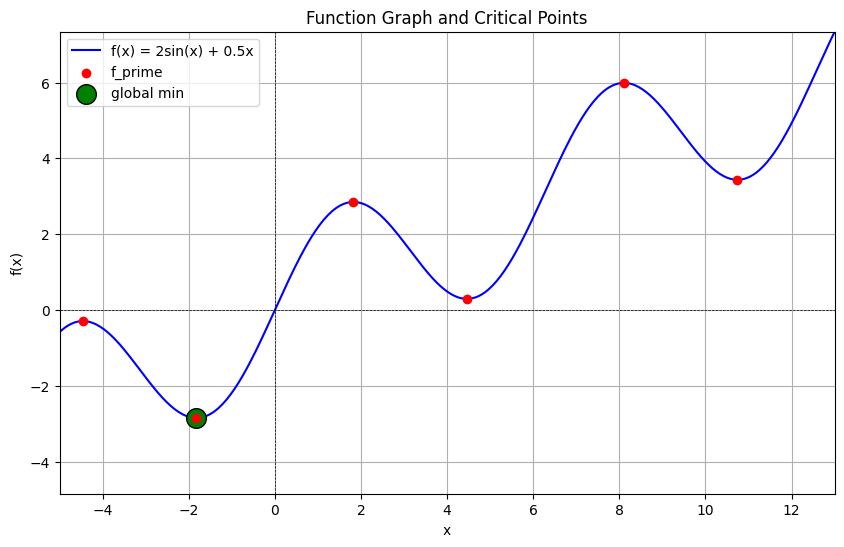

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return 2 * np.sin(x) + 0.5 * x

x_values = np.linspace(-5, 13, 400)  # -5부터 13까지 400개의 점 생성
y_values = f(x_values)  # y 값 계산

def critical_points_in_range(): # 기울기가 0이 되는 지점 탐색
    cos_value = -0.25
    angles = np.arccos(cos_value)  # arccos를 통해 주어진 값의 각도를 구함
    solutions = [angles, -angles]

    n_values = np.arange(-3, 4)  # -3π 부터 3π까지
    for n in n_values:
        for solution in solutions:
            x_value = solution + n * 2 * np.pi
            if -5 <= x_value <= 13:
                yield x_value

# 기울기가 0인 x 값들
critical_points = list(critical_points_in_range())
critical_points.sort()

# y 값 계산 (x 값과 그에 대응하는 y 값을 튜플로 저장)
y_values = [(x, f(x)) for x in critical_points]

# 가장 작은 y값의 위치 찾기
min_y_point = min(y_values, key=lambda item: item[1])

print("기울기가 0인 지점들:", critical_points)
print("최소값 : ", min_y_point[1])

# 그래프 그리기
plt.figure(figsize=(10, 6))
plt.plot(x_values, f(x_values), label='f(x) = 2sin(x) + 0.5x', color='blue')
plt.scatter(critical_points, f(np.array(critical_points)), color='red', label='f_prime', zorder=10)
plt.scatter(min_y_point[0], min_y_point[1], color='green', s=200, label='global min', zorder=6, edgecolor='black')
plt.title('Function Graph and Critical Points')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.axhline(0, color='black', linewidth=0.5, ls='--')
plt.axvline(0, color='black', linewidth=0.5, ls='--')
plt.grid()
plt.legend()
plt.xlim(-5, 13)
plt.ylim(min(f(x_values))-2, max(f(x_values)))
plt.show()

## 1-2. 뉴턴법

In [12]:
import numpy as np

# 도함수 정의
def f_prime(x): 
    return 2 * np.cos(x) + 0.5 

# 초기값 설정
x0 = 13
tolerance = 1e-6  # 수렴 허용 오차
max_iterations = 100  # 최대 반복 횟수
iteration = 0

# 뉴턴법 적용
while iteration < max_iterations:
    slope = f_prime(x0)  # 현재 기울기 계산
    
    # 기울기가 0에 도달할 때까지 이동
    if slope > 0:  # 기울기가 양수면 왼쪽으로
        x1 = x0 - slope * 0.1  # 작은 스텝으로 왼쪽으로 이동
    else:  # 기울기가 음수면 오른쪽으로
        x1 = x0 - slope * 0.1  # 작은 스텝으로 오른쪽으로 이동

    # x의 범위 제한
    if x1 < -5 or x1 > 13:
        break

    # 기울기가 0인지 검사
    if abs(f_prime(x1)) < tolerance:
        break

    x0 = x1  # 업데이트
    iteration += 1

x1, f(x1)  # 기울기가 0인 지점과 해당 함수 값 반환

(10.742894484624905, 3.434955343107588)

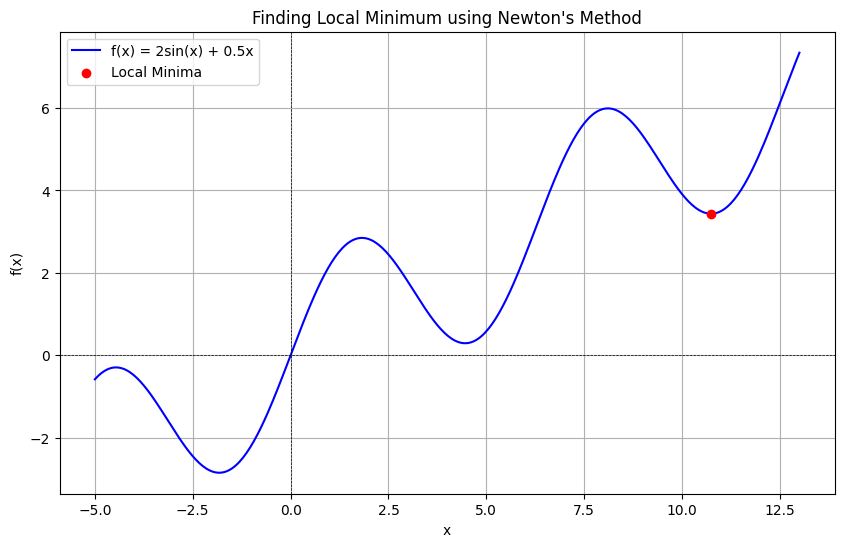

In [13]:
x_values = np.linspace(-5, 13, 400)
y_values = f(x_values)

plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, label='f(x) = 2sin(x) + 0.5x', color='blue')
plt.scatter(x1, f(x1), color='red', label='Local Minima', zorder=5)
plt.title('Finding Local Minimum using Newton\'s Method')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
plt.grid()
plt.legend()
plt.show()

### 뉴턴법 결과
- 도함수의 근사 해를 잘 찾았지만, 이것이 전역 최적해가 아님
- 뉴턴법 자체의 특성 (또는 유사한 지역 탐색 방법의 특성)과 함수의 다봉성 때문에 발생하는 문제
- 전역 최적해를 찾기 위해서는 미분법으로 모든 임계점을 찾고 경계값과 비교하거나, 유전 알고리즘과 같은 전역 최적화 방법을 사용해야 함.

## 1-3. 경사하강법

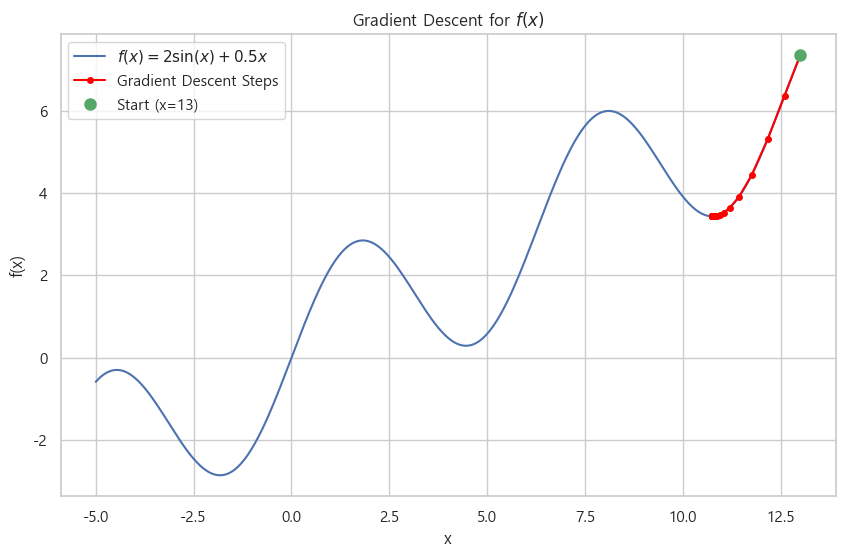

찾은 근사 최소값: x = 10.7429, f(x) = 3.4350


In [179]:
import numpy as np
import matplotlib.pyplot as plt

# 함수 정의
def f(x):
    return 2 * np.sin(x) + 0.5 * x

# 함수의 도함수 정의
def df(x):
    return 2 * np.cos(x) + 0.5

# 경사 하강법 구현 함수
def gradient_descent(initial_x, learning_rate, num_iterations):
    x_history = [initial_x] # x 값의 이력을 저장할 리스트
    f_history = [f(initial_x)] # f(x) 값의 이력을 저장할 리스트
    x = initial_x # 현재 x 값

    for i in range(num_iterations): # 지정된 반복 횟수만큼 반복
        gradient = df(x) # 현재 x에서의 기울기 계산
        x = x - learning_rate * gradient # 기울기 반대 방향으로 x 값 업데이트

        # 선택 사항: x 값이 [-5, 13] 범위를 벗어나지 않도록 경계 체크
        x = np.clip(x, -5, 13)

        x_history.append(x) # 업데이트된 x 값을 이력에 추가
        f_history.append(f(x)) # 업데이트된 f(x) 값을 이력에 추가

    return x_history, f_history # x와 f(x)의 이력 반환

# --- 시각화 ---
# 플롯을 위한 x 범위 정의
x_range = np.linspace(-5, 13, 400)
y_range = f(x_range)

# 초기 매개변수 설정
initial_x = 13.0 # 초기 x 값
learning_rate = 0.1737373
num_iterations = 100 # 반복 횟수 (조절하거나 수렴 기준으로 변경 가능)

# 경사 하강법 실행
x_history, f_history = gradient_descent(initial_x, learning_rate, num_iterations)

# 함수 플롯
plt.figure(figsize=(10, 6)) # 플롯 크기 설정
plt.plot(x_range, y_range, label='$f(x) = 2\sin(x) + 0.5x$') # 함수 그래프 플롯

# 경사 하강법 스텝 플롯
plt.plot(x_history, f_history, 'o-', color='red', markersize=4, label='Gradient Descent Steps') # 경사 하강법 이동 경로 플롯

# 시작 지점 표시
plt.plot(x_history[0], f_history[0], 'go', markersize=8, label='Start (x=13)') # 시작 지점 표시

# 레이블 및 제목 추가
plt.xlabel('x') # x축 레이블
plt.ylabel('f(x)') # y축 레이블
plt.title('Gradient Descent for $f(x)$') # 플롯 제목
plt.legend() # 범례 표시
plt.grid(True) # 그리드 표시
plt.show() # 플롯 보여주기

# 찾은 근사 최소값 출력
print(f"찾은 근사 최소값: x = {x_history[-1]:.4f}, f(x) = {f_history[-1]:.4f}")

## 모멘텀 도입

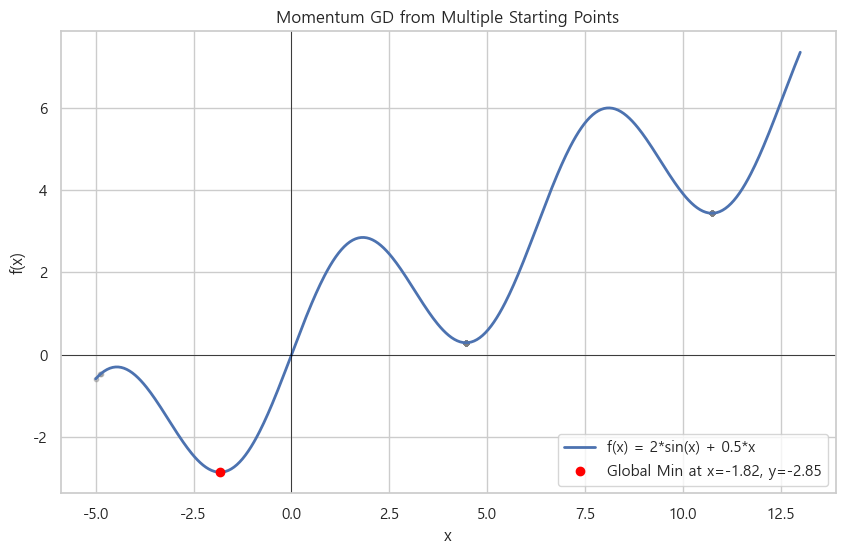

momentum_score: -1.3636363636363633, 
x: -1.8234684114155872, 
y: -2.8482299640075586


In [108]:
# sympy 함수 사용을 위한 재정의
import sympy as sp

# 심볼릭 변수 및 함수 정의
x_sym = sp.symbols('x')
f_sym = 2 * sp.sin(x_sym) + 0.5 * x_sym

# 도함수 계산
f_prime = sp.diff(f_sym, x_sym)

# 수치 계산을 위한 함수 변환
f_lambdified = sp.lambdify(x_sym, f_sym, modules=["numpy"])
f_prime_lambdified = sp.lambdify(x_sym, f_prime, modules=["numpy"])

# 모멘텀을 사용하는 경사하강법 함수 정의
def gradient_descent_with_momentum(f_prime, x0, learning_rate=0.01, momentum=0.9, tol=1e-6, max_iter=1000, x_min=-5, x_max=13):
    x = x0
    v = 0
    for _ in range(max_iter):
        grad = f_prime(x)
        v = momentum * v - learning_rate * grad
        x_new = x + v
        if x_new < x_min or x_new > x_max:
            break
        if abs(x_new - x) < tol:
            return x_new
        x = x_new
    return x

# 초기값을 linspace로 설정
initial_values = np.linspace(-5, 13, 100)
results = []

for x0 in initial_values:
    x_opt = gradient_descent_with_momentum(
        f_prime_lambdified, x0, learning_rate=0.1, momentum=0.9, max_iter=1000
    )
    y_opt = f_lambdified(x_opt)
    results.append((x0, x_opt, y_opt))

# 최소값 탐색
best_result = min(results, key=lambda x: x[2])  # y_opt 기준 최소값

plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, label='f(x) = 2*sin(x) + 0.5*x', linewidth=2)

# 여러 초기값에서 수렴한 최적점 표시
for _, x_opt, y_opt in results:
    plt.scatter(x_opt, y_opt, color='gray', alpha=0.4, s=10)

# 최적 최소값 표시
plt.scatter(best_result[1], best_result[2], color='red', label=f"Global Min at x={best_result[1]:.2f}, y={best_result[2]:.2f}", zorder=5)

plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.title("Momentum GD from Multiple Starting Points")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()

best_result
print(f'momentum_score: {best_result[0]}, \nx: {best_result[1]}, \ny: {best_result[2]}')

## 1-4. 유전알고리즘으로 최적해 탐색

### 코드 리뷰
- 목적함수 정의, 개체 유형(이진, 실수)에 따른 인코딩,  세대 진행에 따라 교차 및 돌연변이 확률 조정
- 파라미터 그리드 정의 후 모든 파라미터 조합(2,095,875개) 탐색
- CPU 코어 수만큼 병렬 프로세스 만들어서 작업 병렬로 처리 후 결과 csv파일로 저장

In [2]:
# 유전 알고리즘 연산자 함수 정의

import random
import copy
import math
import numpy as np

# 1. Selection operators (선택 연산자)

def selection_proportional(individuals):
    """적합도에 비례하여 개체 선택 (룰렛 휠)"""
    total_fitness = sum(ind.fitness for ind in individuals)
    n = len(individuals)
    selected = []

    if n == 0 or total_fitness <= 0:
        return random.sample(individuals, n) if n > 0 else []

    cumulative_fitness = np.cumsum([ind.fitness for ind in individuals])

    for _ in range(n):
        pick = random.random() * total_fitness
        idx = np.searchsorted(cumulative_fitness, pick)
        selected.append(individuals[idx])

    return selected


def selection_rank(individuals):
    """적합도 순위에 따라 개체 선택"""
    sorted_inds = sorted(individuals, key=lambda ind: ind.fitness, reverse=True)
    n = len(sorted_inds)
    if n == 0: return []

    ranks = [n - i for i in range(n)]
    total_rank = sum(ranks)

    selected = []
    if total_rank == 0:
         return random.sample(sorted_inds, n)

    cumulative_ranks = np.cumsum(ranks)

    for _ in range(n):
        pick = random.random() * total_rank
        idx = np.searchsorted(cumulative_ranks, pick)
        selected.append(sorted_inds[idx])

    return selected


def selection_rank_with_elite(individuals, elite_size=0):
    """랭크 선택 및 엘리트 보존"""
    sorted_inds = sorted(individuals, key=lambda ind: ind.fitness, reverse=True)
    n = len(sorted_inds)
    if n == 0: return []

    current_elite_size = min(elite_size, n)
    elites = sorted_inds[:current_elite_size]

    remaining_inds = sorted_inds[current_elite_size:]
    n_remaining = len(remaining_inds)

    selected_from_rest = []
    if n_remaining > 0:
        ranks = [n_remaining - i for i in range(n_remaining)]
        total_rank = sum(ranks)

        if total_rank == 0:
             selected_from_rest = random.sample(remaining_inds, n_remaining)
        else:
            cumulative_ranks = np.cumsum(ranks)
            for _ in range(n_remaining):
                pick = random.random() * total_rank
                idx = np.searchsorted(cumulative_ranks, pick)
                selected_from_rest.append(remaining_inds[idx])

    return elites + selected_from_rest


def selection_stochastic_universal_sampling(individuals):
    """확률적 만능 샘플링 (SUS)"""
    total_fitness = sum(ind.fitness for ind in individuals)
    n = len(individuals)
    selected = []

    if n == 0 or total_fitness <= 0:
        return random.sample(individuals, n) if n > 0 else []

    slot_size = total_fitness / n
    start_point = random.uniform(0, slot_size)
    pointers = [start_point + i * slot_size for i in range(n)]

    cumulative_fitness = np.cumsum([ind.fitness for ind in individuals])
    ind_idx = 0
    for pointer in pointers:
        while ind_idx < n - 1 and cumulative_fitness[ind_idx] < pointer:
            ind_idx += 1
        selected.append(individuals[ind_idx])

    return selected


def selection_tournament(individuals, group_size=2):
    """토너먼트 선택"""
    selected = []
    n = len(individuals)
    if n == 0: return []
    current_group_size = min(group_size, n)
    if current_group_size < 1: current_group_size = 1

    for _ in range(n):
        participants = random.sample(individuals, current_group_size)
        selected.append(max(participants, key=lambda ind: ind.fitness))
    return selected


# 3. Crossover operators (교차 연산자)

def crossover_blend(p1_genes, p2_genes, alpha):
    """실수값 유전자에 대한 블렌드 교차 (BLX-alpha)"""
    c1_genes, c2_genes = copy.copy(p1_genes), copy.copy(p2_genes)
    for i in range(len(c1_genes)):
        g1, g2 = float(p1_genes[i]), float(p2_genes[i])
        diff = abs(g2 - g1)
        low, high = min(g1, g2) - alpha * diff, max(g1, g2) + alpha * diff
        c1_genes[i] = low + random.random() * (high - low)
        c2_genes[i] = low + random.random() * (high - low)
    return [c1_genes, c2_genes]


def crossover_linear(p1_genes, p2_genes, alpha):
    """실수값 유전자에 대한 선형 교차"""
    c1_genes, c2_genes = copy.copy(p1_genes), copy.copy(p2_genes)
    for i in range(len(c1_genes)):
        g1, g2 = float(p1_genes[i]), float(p2_genes[i])
        c1_genes[i] = alpha * g1 + (1 - alpha) * g2
        c2_genes[i] = (1 - alpha) * g1 + alpha * g2
    return [c1_genes, c2_genes]


def cycle_crossover(p1_genes, p2_genes):
    """순열 기반 유전자에 대한 사이클 교차 (CX)"""
    n = len(p1_genes)
    if n != len(p2_genes):
        raise ValueError("Parents must have the same length for cycle crossover.")
    if n == 0: return [copy.copy(p1_genes), copy.copy(p2_genes)]

    c1_genes = [None] * n
    c2_genes = [None] * n
    visited = [False] * n

    for start_index in range(n):
        if not visited[start_index]:
            cycle = []
            current_index = start_index
            while not visited[current_index]:
                visited[current_index] = True
                cycle.append(current_index)
                value_in_p1 = p1_genes[current_index]
                try:
                    current_index = p2_genes.index(value_in_p1)
                except ValueError:
                     print(f"Warning: Value {value_in_p1} not found in parent 2 during cycle crossover.")
                     break

            for idx in cycle:
                c1_genes[idx] = p1_genes[idx]
                c2_genes[idx] = p2_genes[idx]

    for i in range(n):
        if c1_genes[i] is None:
             c1_genes[i] = p2_genes[i]
             c2_genes[i] = p1_genes[i]

    if None in c1_genes or None in c2_genes:
         print(f"Warning: None values remaining after order crossover. c1: {c1_genes}, c2: {c2_genes}")
         available_genes = sorted(list(set(p1_genes) | set(p2_genes)))
         fill_count = (c1_genes.count(None) + c2_genes.count(None))
         if len(available_genes) >= fill_count:
              temp_available_c1 = available_genes[:]
              temp_available_c2 = available_genes[:]
              c1_genes = [g if g is not None else temp_available_c1.pop(0) for g in c1_genes]
              c2_genes = [g if g is not None else temp_available_c2.pop(0) for g in c2_genes]
         else:
              print("Error: Not enough available genes to fill None values.")

    return [c1_genes, c2_genes]


def crossover_n_point(p1_genes, p2_genes, n):
    """N점 교차"""
    length = len(p1_genes)
    if length != len(p2_genes):
        raise ValueError("Parents must have the same length for N-point crossover.")
    if length < 2 or n <= 0: return [copy.copy(p1_genes), copy.copy(p2_genes)]

    max_points = length - 1
    num_points = min(n, max_points)

    if num_points == 0:
        return [copy.copy(p1_genes), copy.copy(p2_genes)]

    points = sorted(random.sample(range(1, length), num_points))

    c1_genes, c2_genes = copy.copy(p1_genes), copy.copy(p2_genes)
    swap = False

    current_point_idx = 0
    start = 0
    while start < length:
        end = length if current_point_idx >= len(points) else points[current_point_idx]

        if swap:
            c1_genes[start:end] = p2_genes[start:end]
            c2_genes[start:end] = p1_genes[start:end]
        else:
            c1_genes[start:end] = p1_genes[start:end]
            c2_genes[start:end] = p2_genes[start:end]

        start = end
        swap = not swap
        current_point_idx += 1

    return [c1_genes, c2_genes]


def crossover_one_point(p1_genes, p2_genes):
    """1점 교차"""
    return crossover_n_point(p1_genes, p2_genes, 1)


def crossover_order(p1_genes, p2_genes):
    """순열 기반 유전자에 대한 순서 교차 (OX)"""
    n = len(p1_genes)
    if n != len(p2_genes):
        raise ValueError("Parents must have the same length for order crossover.")
    if n < 2: return [copy.copy(p1_genes), copy.copy(p2_genes)]

    start, end = sorted(random.sample(range(n), 2))

    c1_genes = [None] * n
    c2_genes = [None] * n

    c1_genes[start:end+1] = p1_genes[start:end+1]
    c2_genes[start:end+1] = p2_genes[start:end+1]

    p1_remaining = [gene for gene in p1_genes if gene not in c2_genes[start:end+1]]
    p2_remaining = [gene for gene in p2_genes if gene not in c1_genes[start:end+1]]

    p1_rem_idx = 0
    p2_rem_idx = 0
    for i in range(n):
        child_idx = (end + 1 + i) % n

        if c1_genes[child_idx] is not None:
             continue

        while p2_rem_idx < len(p2_remaining) and p2_remaining[p2_rem_idx] in c1_genes:
             p2_rem_idx += 1
        if p2_rem_idx < len(p2_remaining):
             c1_genes[child_idx] = p2_remaining[p2_rem_idx]
             p2_rem_idx += 1

    for i in range(n):
        child_idx = (end + 1 + i) % n
        if c2_genes[child_idx] is not None:
             continue

        while p1_rem_idx < len(p1_remaining) and p1_remaining[p1_rem_idx] in c2_genes:
             p1_rem_idx += 1
        if p1_rem_idx < len(p1_remaining):
             c2_genes[child_idx] = p1_remaining[p1_rem_idx]
             p1_rem_idx += 1

    if None in c1_genes or None in c2_genes:
         print(f"Warning: None values remaining after order crossover. c1: {c1_genes}, c2: {c2_genes}")
         available_genes = sorted(list(set(p1_genes) | set(p2_genes)))
         fill_count = (c1_genes.count(None) + c2_genes.count(None))
         if len(available_genes) >= fill_count:
              temp_available_c1 = available_genes[:]
              temp_available_c2 = available_genes[:]
              c1_genes = [g if g is not None else temp_available_c1.pop(0) for g in c1_genes]
              c2_genes = [g if g is not None else temp_available_c2.pop(0) for g in c2_genes]
         else:
              print("Error: Not enough available genes to fill None values.")

    return [c1_genes, c2_genes]


def crossover_uniform(p1_genes, p2_genes, prop):
    """균일 교차"""
    n = len(p1_genes)
    if n != len(p2_genes):
        raise ValueError("Parents must have the same length for uniform crossover.")
    if n == 0: return [copy.copy(p1_genes), copy.copy(p2_genes)]

    c1_genes, c2_genes = copy.copy(p1_genes), copy.copy(p2_genes)
    for i in range(n):
        if random.random() < prop:
            c1_genes[i], c2_genes[i] = p2_genes[i], p1_genes[i]
    return [c1_genes, c2_genes]


# 4. Mutation operators (돌연변이 연산자)

def mutation_random_deviation(ind_genes, mu, sigma, p):
    """실수값 유전자에 대한 랜덤 편차 돌연변이"""
    m_genes = copy.copy(ind_genes)
    for i in range(len(m_genes)):
        if random.random() < p:
            m_genes[i] += random.gauss(mu, sigma)
    return m_genes


def mutation_exchange(ind_genes):
    """교환 돌연변이 (Swap Mutation)"""
    m_genes = copy.copy(ind_genes)
    n = len(m_genes)
    if n < 2:
        return m_genes
    else:
        i, j = random.sample(range(n), 2)
        m_genes[i], m_genes[j] = m_genes[j], m_genes[i]
    return m_genes


def mutation_shift(ind_genes):
    """이동 돌연변이 (Shift Mutation)"""
    m_genes = copy.copy(ind_genes)
    n = len(m_genes)
    if n < 2:
         return m_genes

    from_idx = random.randint(0, n - 1)
    to_idx = random.randint(0, n - 1)

    if from_idx == to_idx:
        return m_genes

    segment = m_genes.pop(from_idx)
    m_genes.insert(to_idx, segment)

    return m_genes


def mutation_bit_flip(ind_genes):
    """비트 플립 돌연변이 (이진 유전자)"""
    m_genes = copy.copy(ind_genes)
    n = len(m_genes)
    if n == 0: return m_genes
    i = random.randint(0, n - 1)
    m_genes[i] = 1 - m_genes[i]
    return m_genes


def mutation_inversion(ind_genes):
    """역전 돌연변이 (Inversion Mutation)"""
    m_genes = copy.copy(ind_genes)
    n = len(m_genes)
    if n < 2:
         return m_genes

    i, j = sorted(random.sample(range(n), 2))
    m_genes[i:j+1] = list(reversed(m_genes[i:j+1]))

    return m_genes


def mutation_shuffle(ind_genes):
    """셔플 돌연변이 (Shuffle Mutation)"""
    m_genes = copy.copy(ind_genes)
    n = len(m_genes)
    if n < 2:
         return m_genes

    i, j = sorted(random.sample(range(n), 2))
    sub_segment = m_genes[i:j+1]
    random.shuffle(sub_segment)
    m_genes[i:j+1] = sub_segment

    return m_genes


# 5. Fitness-driven operators (적합도 기반 연산자)

def mutation_fitness_driven_random_deviation(ind, mu, sigma, p, max_tries=3):
    """적합도 기반 랜덤 편차 돌연변이"""
    IndividualClass = type(ind)
    init_params = {}
    if hasattr(ind, 'bits'):
        init_params['bits'] = ind.bits
        init_params['min_value'] = ind.min_value
        init_params['max_value'] = ind.max_value
    else:
        init_params['min_value'] = ind.min_value
        init_params['max_value'] = ind.max_value

    current_best_mutant = ind

    for _ in range(max_tries):
        mutated_genes = mutation_random_deviation(ind.gene_list, mu, sigma, p)
        new_mutant = IndividualClass(mutated_genes, **init_params)
        if new_mutant.fitness > current_best_mutant.fitness:
            current_best_mutant = new_mutant

    return current_best_mutant


def mutation_fitness_driven_bit_flip(ind, max_tries=3):
    """적합도 기반 비트 플립 돌연변이"""
    IndividualClass = type(ind)
    init_params = {}
    if hasattr(ind, 'bits'):
        init_params['bits'] = ind.bits
        init_params['min_value'] = ind.min_value
        init_params['max_value'] = ind.max_value
    else:
         print("Error: mutation_fitness_driven_bit_flip applied to non-binary individual.")
         return ind

    current_best_mutant = ind

    for _ in range(max_tries):
        mutated_genes = mutation_bit_flip(ind.gene_list)
        new_mutant = IndividualClass(mutated_genes, **init_params)
        if new_mutant.fitness > current_best_mutant.fitness:
            current_best_mutant = new_mutant

    return current_best_mutant

In [3]:
# Main Execution Logic
# 개체 클래스, GARunner, 멀티프로세싱 실행, 파라미터 그리드 및 결과 저장

import random
import numpy as np
import pandas as pd
from itertools import product
from datetime import datetime
import os
import multiprocessing
import time

# 목적 함수 정의
def func(x):
    """최소화할 목적 함수: f(x) = 2sin(x) + 0.5x"""
    x = float(x)
    return 2 * np.sin(x) + 0.5 * x

# 개체 표현 클래스 정의
class RealIndividual:
    """실수 인코딩 개체"""
    def __init__(self, gene_list, min_value=-5, max_value=13):
        if isinstance(gene_list, RealIndividual):
            self.gene_list = [float(g) for g in gene_list.gene_list]
        elif isinstance(gene_list, (int, float)):
             self.gene_list = [float(gene_list)]
        elif isinstance(gene_list, list):
            self.gene_list = [float(g) for g in gene_list]
        else:
             raise TypeError(f"Unsupported type for gene_list: {type(gene_list)}")

        self.min_value = float(min_value)
        self.max_value = float(max_value)

        if self.gene_list:
             self.gene_list[0] = max(min(self.gene_list[0], self.max_value), self.min_value)
        else:
             self.gene_list = [random.uniform(self.min_value, self.max_value)]

        self.fitness = -func(self.gene_list[0]) # 최소화 문제 -> 적합도는 음수

    def get_x(self):
        """디코딩된 x 값 반환"""
        return self.gene_list[0]

    def __str__(self):
        return f'x: {self.get_x():.4f}, f(x): {func(self.get_x()):.4f}, Fitness: {self.fitness:.4f}'

    def __repr__(self):
         return self.__str__()


class BinaryIndividual:
    """이진 인코딩 개체"""
    def __init__(self, gene_list=None, bits=20, min_value=-5, max_value=13):
        self.bits = int(bits)
        self.min_value = float(min_value)
        self.max_value = float(max_value)

        if gene_list is None:
            self.gene_list = [random.randint(0, 1) for _ in range(self.bits)]
        else:
            if isinstance(gene_list, str):
                 self.gene_list = [int(bit) for bit in gene_list]
            elif isinstance(gene_list, list):
                 self.gene_list = [int(bit) for bit in gene_list]
            else:
                 raise TypeError(f"Unsupported type for gene_list: {type(gene_list)}")

            if len(self.gene_list) != self.bits:
                 raise ValueError(f"Gene list length ({len(self.gene_list)}) must match specified bits ({self.bits})")

        self.x = self._decode_binary()
        self.fitness = -func(self.x) # 최소화 문제 -> 적합도는 음수

    def _decode_binary(self):
        """이진 문자열을 실수 값으로 디코딩 (선형 매핑)"""
        if not self.gene_list:
             return self.min_value

        integer_value = 0
        for bit in self.gene_list:
            integer_value = integer_value * 2 + bit

        max_integer_value = (2 ** self.bits) - 1
        if max_integer_value == 0:
             return self.min_value

        range_size = self.max_value - self.min_value
        decoded_x = self.min_value + integer_value * (range_size / max_integer_value)

        return max(min(decoded_x, self.max_value), self.min_value)

    def get_x(self):
        """디코딩된 x 값 반환"""
        return self.x

    def __str__(self):
        binary = ''.join(map(str, self.gene_list))
        return f'Binary: {binary}, x: {self.get_x():.4f}, f(x): {func(self.get_x()):.4f}, Fitness: {self.fitness:.4f}'

    def __repr__(self):
         return self.__str__()


# GARunner 클래스 정의
class GARunner:
    """고정된 파라미터로 단일 GA 실행"""
    def __init__(self, params):
        self.params = params
        self.encoding_type = params['encoding_type']
        self.population_size = params['population_size']
        self.max_generations = params['max_generations']
        self.initial_crossover_prob = params['initial_crossover_prob']
        self.final_crossover_prob = params['final_crossover_prob']
        self.initial_mutation_prob = params['initial_mutation_prob']
        self.final_mutation_prob = params['final_mutation_prob']
        self.elite_size = params['elite_size']
        self.tournament_group_size = params['tournament_group_size']
        self.bits = params.get('bits', None)

        self.convergence_threshold = params.get('convergence_threshold', 1e-6)
        self.convergence_generations = params.get('convergence_generations', 10)

        self.selection_method = params['selection_method']
        self.crossover_method, self.crossover_params = params['crossover_tuple']
        self.mutation_method, self.mutation_params = params['mutation_tuple']

        self.IndividualClass = RealIndividual if self.encoding_type == 'real' else BinaryIndividual

        self.min_value = -5.0
        self.max_value = 13.0


    def get_adaptive_rates(self, generation):
        """세대 진행에 따른 적응적 확률 계산"""
        if self.max_generations <= 1:
             progress = 0
        else:
             progress = generation / (self.max_generations - 1)

        crossover_prob = self.initial_crossover_prob - (self.initial_crossover_prob - self.final_crossover_prob) * progress
        mutation_prob = self.initial_mutation_prob - (self.initial_mutation_prob - self.final_mutation_prob) * progress
        return crossover_prob, mutation_prob

    def run(self):
        """GA 실행"""
        # 개체군 초기화
        population = []
        for _ in range(self.population_size):
            if self.encoding_type == 'binary':
                population.append(self.IndividualClass(bits=self.bits, min_value=self.min_value, max_value=self.max_value))
            else:
                population.append(self.IndividualClass(random.uniform(self.min_value, self.max_value), min_value=self.min_value, max_value=self.max_value))

        # 전체 세대 중 최고의 개체 추적
        best_ever = max(population, key=lambda ind: ind.fitness)
        if self.encoding_type == 'binary':
            best_ever = self.IndividualClass(best_ever.gene_list, bits=self.bits, min_value=self.min_value, max_value=self.max_value)
        else:
            best_ever = self.IndividualClass(best_ever.gene_list, min_value=self.min_value, max_value=self.max_value)

        prev_best_fx = float('inf')
        convergence_count = 0
        generations_run = 0

        for generation in range(self.max_generations):
            generations_run = generation + 1

            crossover_prob, mutation_prob = self.get_adaptive_rates(generation)

            # 선택
            if self.selection_method == selection_rank_with_elite:
                 current_elite_size = min(self.elite_size, self.population_size)
                 selected = self.selection_method(population, elite_size=current_elite_size)
            elif self.selection_method == selection_tournament:
                 current_group_size = min(self.tournament_group_size, self.population_size)
                 selected = self.selection_method(population, group_size=current_group_size)
            else:
                 selected = self.selection_method(population)

            if len(selected) != self.population_size:
                 selected = random.sample(selected, self.population_size)

            # 교차
            offspring = []
            random.shuffle(selected)
            paired_selected = selected
            if len(paired_selected) % 2 != 0:
                 paired_selected = paired_selected[:-1]

            for i in range(0, len(paired_selected), 2):
                p1, p2 = paired_selected[i], paired_selected[i+1]
                if random.random() < crossover_prob:
                    c1_genes, c2_genes = self.crossover_method(p1.gene_list, p2.gene_list, **self.crossover_params)
                    if self.encoding_type == 'binary':
                        offspring.append(self.IndividualClass(c1_genes, bits=self.bits, min_value=self.min_value, max_value=self.max_value))
                        offspring.append(self.IndividualClass(c2_genes, bits=self.bits, min_value=self.min_value, max_value=self.max_value))
                    else:
                        offspring.append(self.IndividualClass(c1_genes, min_value=self.min_value, max_value=self.max_value))
                        offspring.append(self.IndividualClass(c2_genes, min_value=self.min_value, max_value=self.max_value))
                else:
                    if self.encoding_type == 'binary':
                        offspring.append(self.IndividualClass(p1.gene_list, bits=self.bits, min_value=self.min_value, max_value=self.max_value))
                        offspring.append(self.IndividualClass(p2.gene_list, bits=self.bits, min_value=self.min_value, max_value=self.max_value))
                    else:
                        offspring.append(self.IndividualClass(p1.gene_list, min_value=self.min_value, max_value=self.max_value))
                        offspring.append(self.IndividualClass(p2.gene_list, min_value=self.min_value, max_value=self.max_value))

            if len(selected) % 2 != 0:
                 if self.encoding_type == 'binary':
                     offspring.append(self.IndividualClass(selected[-1].gene_list, bits=self.bits, min_value=self.min_value, max_value=self.max_value))
                 else:
                     offspring.append(self.IndividualClass(selected[-1].gene_list, min_value=self.min_value, max_value=self.max_value))

            # 돌연변이
            mutated_offspring = []
            for ind in offspring:
                 if random.random() < mutation_prob:
                    # 적합도 기반 돌연변이는 개체 자체를 반환
                    if self.mutation_method in [mutation_fitness_driven_random_deviation, mutation_fitness_driven_bit_flip]:
                         mutated_ind = self.mutation_method(ind, **self.mutation_params)
                         mutated_offspring.append(mutated_ind)
                    # 일반 돌연변이는 유전자 리스트를 반환
                    else:
                         mutated_genes = self.mutation_method(ind.gene_list, **self.mutation_params)
                         if self.encoding_type == 'binary':
                             mutated_offspring.append(self.IndividualClass(mutated_genes, bits=self.bits, min_value=self.min_value, max_value=self.max_value))
                         else:
                             mutated_offspring.append(self.IndividualClass(mutated_genes, min_value=self.min_value, max_value=self.max_value))
                 else:
                    # 돌연변이 없음, 개체 복사
                    if self.encoding_type == 'binary':
                        mutated_offspring.append(self.IndividualClass(ind.gene_list, bits=self.bits, min_value=self.min_value, max_value=self.max_value))
                    else:
                        mutated_offspring.append(self.IndividualClass(ind.gene_list, min_value=self.min_value, max_value=self.max_value))

            # 세대 교체 및 엘리트 보존
            current_population_best = max(population, key=lambda ind: ind.fitness)
            if current_population_best.fitness > best_ever.fitness:
                 if self.encoding_type == 'binary':
                     best_ever = self.IndividualClass(current_population_best.gene_list, bits=self.bits, min_value=self.min_value, max_value=self.max_value)
                 else:
                     best_ever = self.IndividualClass(current_population_best.gene_list, min_value=self.min_value, max_value=self.max_value)

            mutated_offspring.sort(key=lambda ind: ind.fitness, reverse=True)
            next_population = mutated_offspring[:self.population_size]

            if self.elite_size > 0 and best_ever not in next_population:
                 if next_population:
                      worst_in_next_pop = next_population[-1]
                      if best_ever.fitness > worst_in_next_pop.fitness:
                          if self.encoding_type == 'binary':
                              next_population[-1] = self.IndividualClass(best_ever.gene_list, bits=self.bits, min_value=self.min_value, max_value=self.max_value)
                          else:
                              next_population[-1] = self.IndividualClass(best_ever.gene_list, min_value=self.min_value, max_value=self.max_value)

            while len(next_population) < self.population_size:
                 if self.encoding_type == 'binary':
                     next_population.append(self.IndividualClass(best_ever.gene_list, bits=self.bits, min_value=self.min_value, max_value=self.max_value))
                 else:
                     next_population.append(self.IndividualClass(best_ever.gene_list, min_value=self.min_value, max_value=self.max_value))

            population = next_population

            # 수렴 확인
            current_best_in_pop = population[0]
            current_fx = func(current_best_in_pop.get_x())

            if current_best_in_pop.fitness > best_ever.fitness:
                 if self.encoding_type == 'binary':
                     best_ever = self.IndividualClass(current_best_in_pop.gene_list, bits=self.bits, min_value=self.min_value, max_value=self.max_value)
                 else:
                     best_ever = self.IndividualClass(current_best_in_pop.gene_list, min_value=self.min_value, max_value=self.max_value)

            if abs(current_fx - prev_best_fx) < self.convergence_threshold:
                convergence_count += 1
            else:
                convergence_count = 0

            if convergence_count >= self.convergence_generations:
                break

            prev_best_fx = current_fx

        final_best_fx = func(best_ever.get_x())

        return {
            'generations_run': generations_run,
            'best_fx': final_best_fx,
            'best_x': best_ever.get_x(),
            'encoding_type': self.encoding_type,
            'population_size': self.population_size,
            'max_generations': self.max_generations,
            'initial_crossover_prob': self.initial_crossover_prob,
            'final_crossover_prob': self.final_crossover_prob,
            'initial_mutation_prob': self.initial_mutation_prob,
            'final_mutation_prob': self.final_mutation_prob,
            'elite_size': self.elite_size,
            'tournament_group_size': self.tournament_group_size,
            'bits': self.bits,
            'selection_method': self.selection_method.__name__ if callable(self.selection_method) else str(self.selection_method),
            'crossover_method': self.crossover_method.__name__,
            'crossover_params': str(self.crossover_params),
            'mutation_method': self.mutation_method.__name__,
            'mutation_params': str(self.mutation_params),
            'convergence_threshold': self.convergence_threshold,
            'convergence_generations': self.convergence_generations,
            'best_binary_repr': ''.join(map(str, best_ever.gene_list)) if self.encoding_type == 'binary' and best_ever.gene_list is not None else None,
        }


# 멀티프로세싱 워커 함수
def run_single_trial(params_with_seed):
    """단일 GA 실행을 위한 워커 함수"""
    run_num = params_with_seed['run_number']
    random_seed = params_with_seed['random_seed']

    random.seed(random_seed)
    np.random.seed(random_seed)

    try:
        # GARunner에 필요한 파라미터만 추출
        runner_params = {k: v for k, v in params_with_seed.items() if k not in ['run_number', 'random_seed']}
        runner = GARunner(runner_params)
        result = runner.run()

        result['run_number'] = run_num + 1
        result['random_seed'] = random_seed
        return result

    except Exception as e:
        error_result = params_with_seed.copy()
        error_result['run_number'] = run_num + 1
        error_result['error'] = str(e)
        error_result['generations_run'] = 0
        error_result['best_fx'] = float('nan')
        error_result['best_x'] = float('nan')
        error_result['best_binary_repr'] = None

        # 오류 로깅을 위해 함수/튜플을 문자열로 변환
        error_result['selection_method'] = error_result['selection_method'].__name__ if callable(error_result['selection_method']) else str(error_result['selection_method'])
        error_result['crossover_method'] = error_result['crossover_tuple'][0].__name__ if isinstance(error_result['crossover_tuple'], tuple) and callable(error_result['crossover_tuple'][0]) else str(error_result['crossover_tuple'])
        error_result['crossover_params'] = str(error_result['crossover_tuple'][1]) if isinstance(error_result['crossover_tuple'], tuple) else str(error_result['crossover_tuple'])
        error_result['mutation_method'] = error_result['mutation_tuple'][0].__name__ if isinstance(error_result['mutation_tuple'], tuple) and callable(error_result['mutation_tuple'][0]) else str(error_result['mutation_tuple'])
        error_result['mutation_params'] = str(error_result['mutation_tuple'][1]) if isinstance(error_result['mutation_tuple'], tuple) else str(error_result['mutation_tuple'])

        if 'selection_method' in error_result and callable(error_result['selection_method']): del error_result['selection_method']
        if 'crossover_tuple' in error_result: del error_result['crossover_tuple']
        if 'mutation_tuple' in error_result: del error_result['mutation_tuple']

        return error_result


# --- 파라미터 그리드 정의 ---

# 각 파라미터에 대해 테스트할 후보 값 정의

# 일반 GA 파라미터
population_sizes = [50, 100, 150]
max_generations_list = [100, 200, 300]
crossover_prob_ranges = [(0.9, 0.7), (0.9, 0.9), (0.6, 0.6)] # 적응적, 고정
mutation_prob_ranges = [(0.3, 0.1), (0.1, 0.1), (0.01, 0.01)] # 적응적, 고정
elite_sizes = [0, 1, 5]
tournament_group_sizes = [2, 3, 5]

# 이진 인코딩 특정 파라미터
binary_bits_list = [16, 24, 32]

# 연산자 옵션 (함수, {파라미터}) - 인코딩별 분리

# 선택 연산자 (함수 직접 전달)
selection_options = [
    selection_proportional,
    selection_rank,
    selection_rank_with_elite,
    selection_stochastic_universal_sampling,
    selection_tournament,
]

# 실수값 교차 옵션
real_crossover_options = [
    (crossover_blend, {'alpha': 0.0}),
    (crossover_blend, {'alpha': 0.5}),
    (crossover_blend, {'alpha': 1.0}),
    (crossover_blend, {'alpha': 1.5}),
    (crossover_linear, {'alpha': 0.5}),
]

# 실수값 돌연변이 옵션
real_mutation_options = [
    (mutation_random_deviation, {'mu': 0, 'sigma': 0.1, 'p': 1.0}),
    (mutation_random_deviation, {'mu': 0, 'sigma': 0.5, 'p': 1.0}),
    (mutation_random_deviation, {'mu': 0, 'sigma': 1.0, 'p': 1.0}),
    (mutation_random_deviation, {'mu': 0, 'sigma': 0.5, 'p': 0.5}),
    (mutation_fitness_driven_random_deviation, {'mu': 0, 'sigma': 1.0, 'p': 1.0, 'max_tries': 5}),
]

# 이진 교차 옵션
binary_crossover_options = [
    (crossover_one_point, {}),
    (crossover_n_point, {'n': 2}),
    (crossover_n_point, {'n': 5}),
    (crossover_uniform, {'prop': 0.5}),
    (crossover_uniform, {'prop': 0.8}),
]

# 이진 돌연변이 옵션
binary_mutation_options = [
    (mutation_bit_flip, {}),
    (mutation_exchange, {}),
    (mutation_shift, {}),
    (mutation_inversion, {}),
    (mutation_shuffle, {}),
    (mutation_fitness_driven_bit_flip, {'max_tries': 5}),
]


# --- 모든 파라미터 조합 생성 ---

all_combinations_params = []

general_params_product = product(
    population_sizes,
    max_generations_list,
    crossover_prob_ranges,
    mutation_prob_ranges,
    elite_sizes,
    tournament_group_sizes,
    selection_options,
)

for (pop_size, max_gen, (init_cx, final_cx), (init_mut, final_mut), elite_sz, tourn_sz, sel_method) in general_params_product:
    for encoding in ['real', 'binary']:
        if encoding == 'real':
            current_crossover_options = real_crossover_options
            current_mutation_options = real_mutation_options
            current_bits_list = [None]
        else:
            current_crossover_options = binary_crossover_options
            current_mutation_options = binary_mutation_options
            current_bits_list = binary_bits_list

        encoding_specific_product = product(
            current_bits_list,
            current_crossover_options,
            current_mutation_options,
        )

        for (bits, cx_tuple, mut_tuple) in encoding_specific_product:
            combo_params = {
                'encoding_type': encoding,
                'population_size': pop_size,
                'max_generations': max_gen,
                'initial_crossover_prob': init_cx,
                'final_crossover_prob': final_cx,
                'initial_mutation_prob': init_mut,
                'final_mutation_prob': final_mut,
                'elite_size': elite_sz,
                'tournament_group_size': tourn_sz,
                'bits': bits,
                'selection_method': sel_method, # 함수 객체 저장
                'crossover_tuple': cx_tuple, # (함수 객체, 파라미터 dict) 튜플 저장
                'mutation_tuple': mut_tuple, # (함수 객체, 파라미터 dict) 튜플 저장
            }
            all_combinations_params.append(combo_params)

print(f"생성된 고유 파라미터 조합 수: {len(all_combinations_params)}")


# --- 멀티프로세싱을 위한 작업 준비 ---

num_runs_per_combination = 10
tasks = []
base_seed_counter = int(datetime.now().timestamp())

for i, params in enumerate(all_combinations_params):
    combination_base_seed = base_seed_counter + i * num_runs_per_combination
    for run_num in range(num_runs_per_combination):
        trial_params = params.copy()
        trial_params['run_number'] = run_num
        trial_params['random_seed'] = combination_base_seed + run_num
        tasks.append(trial_params)

print(f"총 실행할 GA 시뮬레이션 수: {len(tasks)}")


# --- 멀티프로세싱을 사용하여 실험 실행 ---

num_processes = multiprocessing.cpu_count()
print(f"\n{num_processes}개의 CPU 코어를 사용하여 실험 실행...")

all_results = []
start_time = time.time()

with multiprocessing.Pool(processes=num_processes) as pool:
    # imap_unordered로 비동기 실행 및 결과 수집
    results_iterator = pool.imap_unordered(run_single_trial, tasks, chunksize=10)

    # 결과 도착 시 처리 및 진행 상황 출력
    for i, result in enumerate(results_iterator):
        all_results.append(result)
        if (i + 1) % 100 == 0 or (i + 1) == len(tasks):
            elapsed_time = time.time() - start_time
            avg_time_per_run = elapsed_time / (i + 1) if (i + 1) > 0 else 0
            estimated_total_time = avg_time_per_run * len(tasks)
            remaining_time = estimated_total_time - elapsed_time
            print(f"  처리 완료: {i + 1}/{len(tasks)} | 경과 시간: {elapsed_time:.2f}s | 남은 시간 추정: {remaining_time:.2f}s")

print("\n실험 완료.")

# --- 결과 저장 ---

result_dir = "ga_optimization_results"
os.makedirs(result_dir, exist_ok=True)

df = pd.DataFrame(all_results)
filename = os.path.join(result_dir, f"ga_results_multiprocessing_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv")
df.to_csv(filename, index=False, encoding='utf-8-sig')

print(f"\n결과가 {filename} 파일에 저장되었습니다.")


생성된 고유 파라미터 조합 수: 419175
총 실행할 GA 시뮬레이션 수: 2095875

80개의 CPU 코어를 사용하여 실험 실행...
  처리 완료: 100/2095875 | 경과 시간: 2.66s | 남은 시간 추정: 55753.83s
  처리 완료: 200/2095875 | 경과 시간: 2.98s | 남은 시간 추정: 31197.68s
  처리 완료: 300/2095875 | 경과 시간: 3.15s | 남은 시간 추정: 22021.84s
  처리 완료: 400/2095875 | 경과 시간: 3.30s | 남은 시간 추정: 17307.23s
  처리 완료: 500/2095875 | 경과 시간: 3.57s | 남은 시간 추정: 14964.65s
  처리 완료: 600/2095875 | 경과 시간: 3.70s | 남은 시간 추정: 12928.41s
  처리 완료: 700/2095875 | 경과 시간: 3.84s | 남은 시간 추정: 11494.39s
  처리 완료: 800/2095875 | 경과 시간: 3.90s | 남은 시간 추정: 10213.31s
  처리 완료: 900/2095875 | 경과 시간: 4.06s | 남은 시간 추정: 9455.99s
  처리 완료: 1000/2095875 | 경과 시간: 4.19s | 남은 시간 추정: 8783.14s
  처리 완료: 1100/2095875 | 경과 시간: 4.29s | 남은 시간 추정: 8174.48s
  처리 완료: 1200/2095875 | 경과 시간: 4.38s | 남은 시간 추정: 7648.91s
  처리 완료: 1300/2095875 | 경과 시간: 4.52s | 남은 시간 추정: 7284.38s
  처리 완료: 1400/2095875 | 경과 시간: 4.61s | 남은 시간 추정: 6894.80s
  처리 완료: 1500/2095875 | 경과 시간: 4.69s | 남은 시간 추정: 6546.60s
  처리 완료: 1600/2095875 | 경과 시간: 4.80s | 남은 시간 추정: 627

In [1]:
import pandas as pd
file_path = 'csv_결과/results/ga_results_multiprocessing_20250504_095724.csv'

df = pd.read_csv(file_path)

In [2]:
df

,generations_run,best_fx,best_x,encoding_type,population_size,max_generations,initial_crossover_prob,final_crossover_prob,initial_mutation_prob,final_mutation_prob,...,selection_method,crossover_method,crossover_params,mutation_method,mutation_params,convergence_threshold,convergence_generations,best_binary_repr,run_number,random_seed
0,17,-2.848230,-1.823477,real,50,100,0.9,0.7,0.30,0.10,...,selection_rank,crossover_blend,{'alpha': 0.0},mutation_random_deviation,"{'mu': 0, 'sigma': 0.5, 'p': 0.5}",0.000001,10,NaN,1,1746346955
1,17,-2.848230,-1.823402,real,50,100,0.9,0.7,0.30,0.10,...,selection_rank,crossover_blend,{'alpha': 0.0},mutation_random_deviation,"{'mu': 0, 'sigma': 0.5, 'p': 0.5}",0.000001,10,NaN,2,1746346956
2,17,-2.848230,-1.823477,real,50,100,0.9,0.7,0.30,0.10,...,selection_rank,crossover_blend,{'alpha': 0.0},mutation_random_deviation,"{'mu': 0, 'sigma': 0.5, 'p': 0.5}",0.000001,10,NaN,3,1746346957
3,16,-2.848230,-1.823476,real,50,100,0.9,0.7,0.30,0.10,...,selection_rank,crossover_blend,{'alpha': 0.0},mutation_random_deviation,"{'mu': 0, 'sigma': 0.5, 'p': 0.5}",0.000001,10,NaN,4,1746346958
4,24,-2.848230,-1.823458,real,50,100,0.9,0.7,0.30,0.10,...,selection_rank,crossover_blend,{'alpha': 0.0},mutation_random_deviation,"{'mu': 0, 'sigma': 0.5, 'p': 0.5}",0.000001,10,NaN,5,1746346959
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2095870,162,-2.848229,-1.822650,binary,150,300,0.6,0.6,0.01,0.01,...,selection_rank_with_elite,crossover_uniform,{'prop': 0.5},mutation_shuffle,{},0.000001,10,00101101001100000110000001111000,1,1748441050
2095871,16,-2.848230,-1.823050,binary,150,300,0.6,0.6,0.01,0.01,...,selection_rank_with_elite,crossover_uniform,{'prop': 0.5},mutation_shuffle,{},0.000001,10,00101101001011101110101111001010,2,1748441051
2095872,189,-2.848227,-1.821632,binary,150,300,0.6,0.6,0.01,0.01,...,selection_rank_with_elite,crossover_uniform,{'prop': 0.5},mutation_shuffle,{},0.000001,10,00101101001101000001010101111110,3,1748441052
2095873,75,-2.848229,-1.824292,binary,150,300,0.6,0.6,0.01,0.01,...,selection_rank_with_elite,crossover_uniform,{'prop': 0.5},mutation_shuffle,{},0.000001,10,00101101001010100110010111110000,4,1748441053


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2095875 entries, 0 to 2095874
Data columns (total 23 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   generations_run          int64  
 1   best_fx                  float64
 2   best_x                   float64
 3   encoding_type            object 
 4   population_size          int64  
 5   max_generations          int64  
 6   initial_crossover_prob   float64
 7   final_crossover_prob     float64
 8   initial_mutation_prob    float64
 9   final_mutation_prob      float64
 10  elite_size               int64  
 11  tournament_group_size    int64  
 12  bits                     float64
 13  selection_method         object 
 14  crossover_method         object 
 15  crossover_params         object 
 16  mutation_method          object 
 17  mutation_params          object 
 18  convergence_threshold    float64
 19  convergence_generations  int64  
 20  best_binary_repr         object 
 21  run_numb

In [24]:
df['encoding_type']

0            real
1            real
2            real
3            real
4            real
            ...  
2095870    binary
2095871    binary
2095872    binary
2095873    binary
2095874    binary
Name: encoding_type, Length: 2095875, dtype: object

In [4]:
df_success = df[df['error'].isnull()].copy()
df_success # 에러 컬럼이 생성되지 않음 -> 실행 중 오류 발생한 경우가 없음(정상)

KeyError: 'error'

In [26]:
# 파라미터 조합을 정의하는 컬럼 리스트 생성 (run_number, random_seed, best_fx, best_x, generations_run, best_binary_repr 제외)
param_cols = [col for col in df.columns if col not in ['generations_run', 'best_fx', 'best_x', 'best_binary_repr', 'run_number', 'random_seed', 'bits']]
param_cols

['encoding_type',
 'population_size',
 'max_generations',
 'initial_crossover_prob',
 'final_crossover_prob',
 'initial_mutation_prob',
 'final_mutation_prob',
 'elite_size',
 'tournament_group_size',
 'selection_method',
 'crossover_method',
 'crossover_params',
 'mutation_method',
 'mutation_params',
 'convergence_threshold',
 'convergence_generations']

### 상관관계 분석

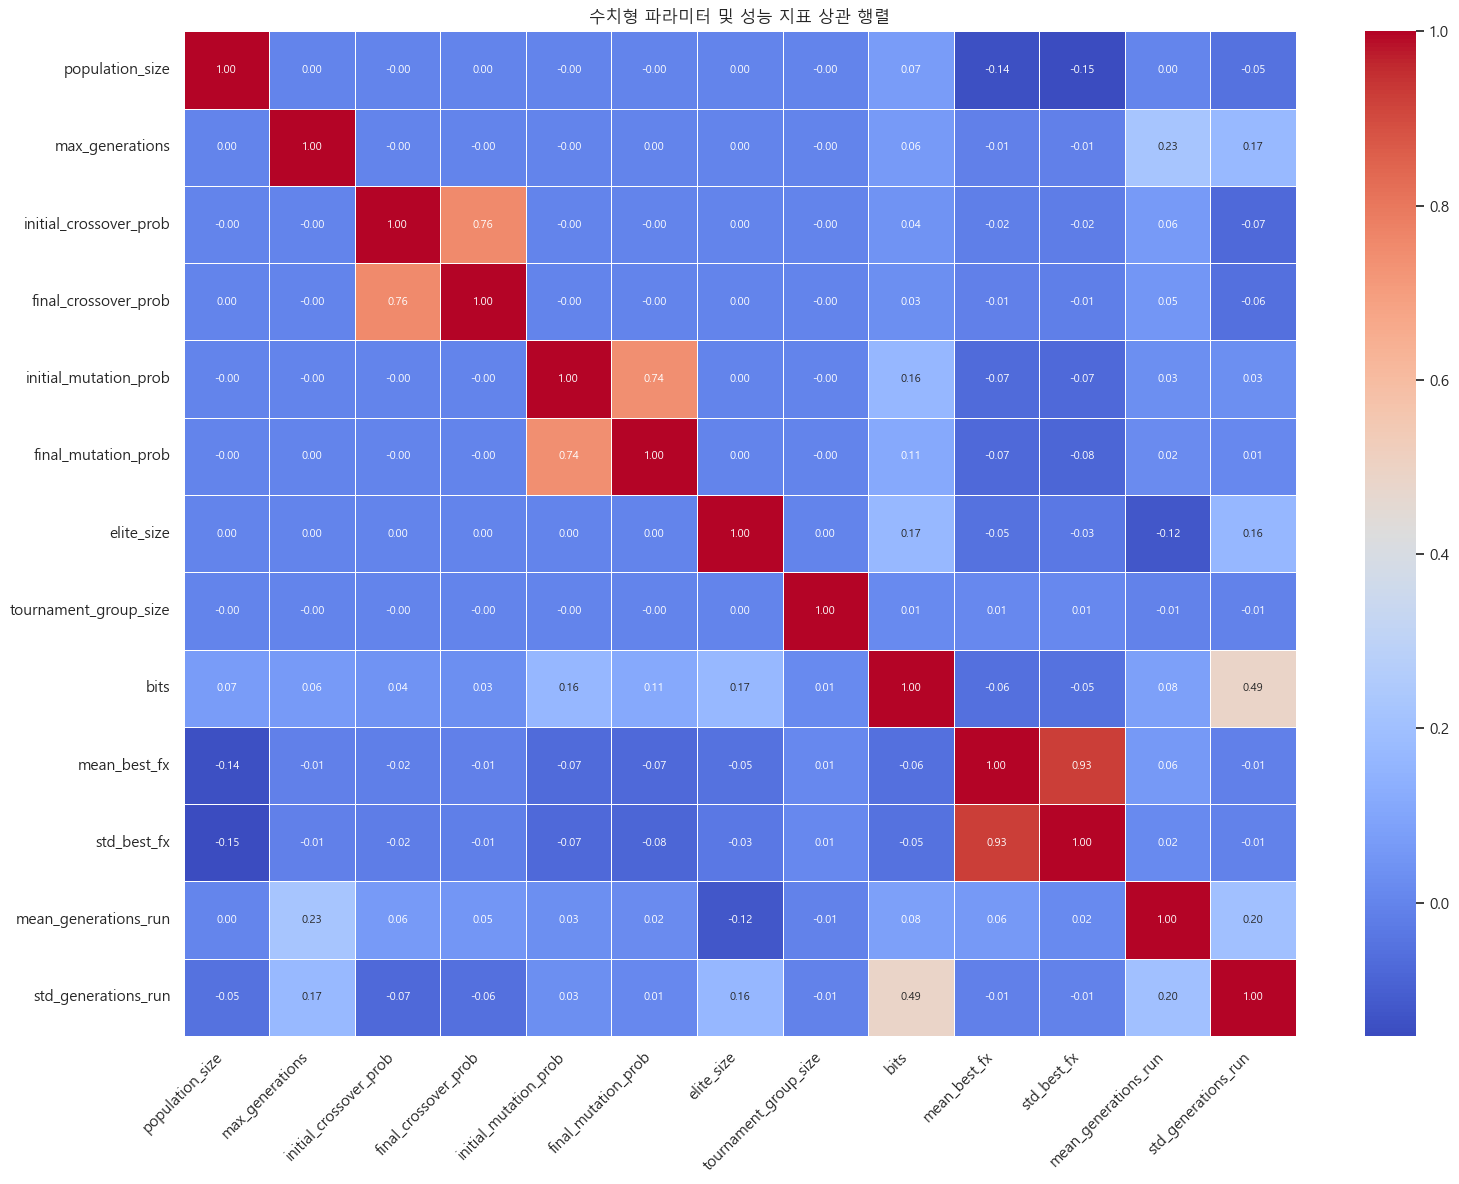

In [101]:
# 파라미터 조합별 결과 집계
grouped_results = df.groupby(param_cols).agg(
    mean_best_fx=('best_fx', 'mean'),
    min_best_fx=('best_fx', 'min'),
    std_best_fx=('best_fx', 'std'),
    mean_generations_run=('generations_run', 'mean'),
    std_generations_run=('generations_run', 'std'),
    num_runs=('best_fx', 'count'),
    bits=('bits', 'first') # bits 컬럼 다시 포함
).reset_index()

# --- 상관관계 분석을 위한 데이터 준비 ---

# 연산자별 특정 파라미터 값을 추출하여 새로운 컬럼으로 추가
# ast.literal_eval을 사용하여 문자열 딕셔너리를 파싱합니다.
def safe_literal_eval(param_str):
    """안전하게 문자열을 파이썬 객체로 변환"""
    try:
        if pd.isna(param_str): # NaN 체크
            return {}
        return ast.literal_eval(param_str)
    except:
        return {} # 파싱 오류 시 빈 딕셔너리 반환

grouped_results['alpha'] = np.nan
grouped_results['sigma'] = np.nan
grouped_results['p_mut'] = np.nan
grouped_results['max_tries_mut'] = np.nan
grouped_results['n_crossover'] = np.nan
grouped_results['prop_crossover'] = np.nan

for index, row in grouped_results.iterrows():
    crossover_params_dict = safe_literal_eval(row['crossover_params'])
    mutation_params_dict = safe_literal_eval(row['mutation_params'])

    # 교차 연산자 특정 파라미터 추출
    if row['crossover_method'] in ['crossover_blend', 'crossover_linear']:
        if 'alpha' in crossover_params_dict:
            grouped_results.loc[index, 'alpha'] = crossover_params_dict['alpha']
    elif row['crossover_method'] == 'crossover_n_point':
         if 'n' in crossover_params_dict:
             grouped_results.loc[index, 'n_crossover'] = crossover_params_dict['n']
    elif row['crossover_method'] == 'crossover_uniform':
         if 'prop' in crossover_params_dict:
             grouped_results.loc[index, 'prop_crossover'] = crossover_params_dict['prop']

    # 돌연변이 연산자 특정 파라미터 추출
    if row['mutation_method'] in ['mutation_random_deviation', 'mutation_fitness_driven_random_deviation']:
        # 'mu'는 현재 그리드에서 항상 0이므로 분석에서 제외
        if 'sigma' in mutation_params_dict:
            grouped_results.loc[index, 'sigma'] = mutation_params_dict['sigma']
        if 'p' in mutation_params_dict:
            grouped_results.loc[index, 'p_mut'] = mutation_params_dict['p']
        if 'max_tries' in mutation_params_dict:
             grouped_results.loc[index, 'max_tries_mut'] = mutation_params_dict['max_tries']
    elif row['mutation_method'] == 'mutation_fitness_driven_bit_flip':
         if 'max_tries' in mutation_params_dict:
              grouped_results.loc[index, 'max_tries_mut'] = mutation_params_dict['max_tries']


# 상관 분석에 사용할 수치형 컬럼 선택
# 범주형 컬럼 및 원본 파라미터 문자열 컬럼 제외
numerical_cols_for_correlation = [
    'population_size',
    'max_generations',
    'initial_crossover_prob',
    'final_crossover_prob',
    'initial_mutation_prob',
    'final_mutation_prob',
    'elite_size',
    'tournament_group_size',
    'bits', # 이진 인코딩에서만 유효 (NaN 포함)
    'alpha', # Crossover Blend/Linear alpha (NaN 포함)
    'sigma', # Mutation Random Deviation sigma (NaN 포함)
    'p_mut', # Mutation Random Deviation p (NaN 포함)
    'max_tries_mut', # Fitness-driven mutations max_tries (NaN 포함)
    'n_crossover', # N-Point Crossover n (NaN 포함)
    'prop_crossover', # Uniform Crossover prop (NaN 포함)
    'mean_best_fx',
    'std_best_fx',
    'mean_generations_run',
    'std_generations_run',
]

# 실제 데이터프레임에 존재하는 컬럼만 선택
numerical_cols_present = [col for col in numerical_cols_for_correlation if col in grouped_results.columns]

# 모든 값이 NaN인 컬럼 제외 (상관 분석 의미 없음)
numerical_cols_present = [col for col in numerical_cols_present if not grouped_results[col].isnull().all()]

# 상관 행렬 계산 (Pearson 상관 계수 사용, NaN 값은 해당 쌍에서 제외됨)
correlation_matrix = grouped_results[numerical_cols_present].corr()

# --- 상관 행렬 시각화 (히트맵) ---

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, annot_kws={"size": 8})
plt.title('수치형 파라미터 및 성능 지표 상관 행렬')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 상관 분석 결과
- 대부분의 수치형 파라미터가 mean_best_fx나 mean_generations_run과 강한 선형적인 개별 관계를 갖지 않음
- 유전 알고리즘의 성능이 개별 수치 파라미터의 선형 효과보다는 범주형 파라미터(연산자 종류, 인코딩 타입)나 파라미터 간의 복잡한 상호작용에 더 크게 영향을 받을 수 있음을 확인
- 실수 파라미터의 영향보다는 범주형 변수의 영향을 파악해야 함.

In [27]:
# 파라미터 조합별로 그룹핑하고 결과 지표 집계
# best_fx는 최소화 문제이므로 평균과 최소값, 표준편차를 주로 확인
# generations_run은 수렴 속도이므로 평균을 주로 확인
grouped_results = df.groupby(param_cols).agg(
    mean_best_fx=('best_fx', 'mean'),
    min_best_fx=('best_fx', 'min'),
    std_best_fx=('best_fx', 'std'), # 성능의 일관성 (표준편차가 작을수록 일관적)
    mean_generations_run=('generations_run', 'mean'),
    std_generations_run=('generations_run', 'std'),
    num_runs=('best_fx', 'count') # 해당 조합의 성공 실행 횟수 (5가 정상)
).reset_index()

print(f"성공적으로 완료된 고유 파라미터 조합 수: {len(grouped_results)}")
grouped_results.head()

성공적으로 완료된 고유 파라미터 조합 수: 200475


,encoding_type,population_size,max_generations,initial_crossover_prob,final_crossover_prob,initial_mutation_prob,final_mutation_prob,elite_size,tournament_group_size,selection_method,...,mutation_method,mutation_params,convergence_threshold,convergence_generations,mean_best_fx,min_best_fx,std_best_fx,mean_generations_run,std_generations_run,num_runs
0,binary,50,100,0.6,0.6,0.01,0.01,0,2,selection_proportional,...,mutation_bit_flip,{},0.000001,10,-2.848013,-2.84823,0.000406,100.000000,0.000000,15
1,binary,50,100,0.6,0.6,0.01,0.01,0,2,selection_proportional,...,mutation_exchange,{},0.000001,10,-2.847996,-2.84823,0.000547,100.000000,0.000000,15
2,binary,50,100,0.6,0.6,0.01,0.01,0,2,selection_proportional,...,mutation_fitness_driven_bit_flip,{'max_tries': 5},0.000001,10,-2.848149,-2.84823,0.000180,95.333333,18.073922,15
3,binary,50,100,0.6,0.6,0.01,0.01,0,2,selection_proportional,...,mutation_inversion,{},0.000001,10,-2.848163,-2.84823,0.000148,100.000000,0.000000,15
4,binary,50,100,0.6,0.6,0.01,0.01,0,2,selection_proportional,...,mutation_shift,{},0.000001,10,-2.848051,-2.84823,0.000288,99.000000,3.872983,15


In [80]:
# 평균 성능 기준 최상위 조합 확인
top_performing_combinations = grouped_results.sort_values(by='mean_best_fx', ascending=True)
print("\n평균 성능 기준 최상위 10개 파라미터 조합:")
top_performing_combinations.head(10)


평균 성능 기준 최상위 10개 파라미터 조합:


,encoding_type,population_size,max_generations,initial_crossover_prob,final_crossover_prob,initial_mutation_prob,final_mutation_prob,elite_size,tournament_group_size,selection_method,...,convergence_threshold,convergence_generations,mean_best_fx,min_best_fx,std_best_fx,mean_generations_run,std_generations_run,num_runs,crossover_prob_range,mutation_prob_range
200474,real,150,300,0.9,0.9,0.3,0.1,5,5,selection_tournament,...,0.000001,10,-2.84823,-2.84823,3.140185e-16,13.6,0.547723,5,"(0.9, 0.9)","(0.3, 0.1)"
186576,real,150,200,0.9,0.7,0.3,0.1,1,5,selection_tournament,...,0.000001,10,-2.84823,-2.84823,0.000000e+00,13.2,0.447214,5,"(0.9, 0.7)","(0.3, 0.1)"
186577,real,150,200,0.9,0.7,0.3,0.1,1,5,selection_tournament,...,0.000001,10,-2.84823,-2.84823,0.000000e+00,12.8,0.836660,5,"(0.9, 0.7)","(0.3, 0.1)"
186578,real,150,200,0.9,0.7,0.3,0.1,1,5,selection_tournament,...,0.000001,10,-2.84823,-2.84823,0.000000e+00,12.8,0.836660,5,"(0.9, 0.7)","(0.3, 0.1)"
186579,real,150,200,0.9,0.7,0.3,0.1,1,5,selection_tournament,...,0.000001,10,-2.84823,-2.84823,2.220446e-16,12.8,1.095445,5,"(0.9, 0.7)","(0.3, 0.1)"
186580,real,150,200,0.9,0.7,0.3,0.1,1,5,selection_tournament,...,0.000001,10,-2.84823,-2.84823,0.000000e+00,12.2,0.836660,5,"(0.9, 0.7)","(0.3, 0.1)"
186581,real,150,200,0.9,0.7,0.3,0.1,1,5,selection_tournament,...,0.000001,10,-2.84823,-2.84823,3.140185e-16,13.2,0.447214,5,"(0.9, 0.7)","(0.3, 0.1)"
186582,real,150,200,0.9,0.7,0.3,0.1,1,5,selection_tournament,...,0.000001,10,-2.84823,-2.84823,0.000000e+00,12.6,0.547723,5,"(0.9, 0.7)","(0.3, 0.1)"
186583,real,150,200,0.9,0.7,0.3,0.1,1,5,selection_tournament,...,0.000001,10,-2.84823,-2.84823,3.845925e-16,12.8,0.836660,5,"(0.9, 0.7)","(0.3, 0.1)"
186585,real,150,200,0.9,0.7,0.3,0.1,1,5,selection_tournament,...,0.000001,10,-2.84823,-2.84823,3.845925e-16,12.8,1.303840,5,"(0.9, 0.7)","(0.3, 0.1)"


In [85]:
# 표준편차도 함께 고려하여 일관성 있는 고성능 조합 찾기(평균 성능으로 1차 정렬, 표준편차로 2차 정렬)
# 평균 성능이 좋으면서 표준편차가 작은 조합을 찾기
top_consistent_combinations = grouped_results.sort_values(by=['mean_best_fx', 'std_best_fx'], ascending=[True, True])
print("\n표준편차도 함께 고려한 최상위 10개 파라미터 조합:")
top_consistent_combinations.head(10)


표준편차도 함께 고려한 최상위 10개 파라미터 조합:


,encoding_type,population_size,max_generations,initial_crossover_prob,final_crossover_prob,initial_mutation_prob,final_mutation_prob,elite_size,tournament_group_size,selection_method,...,convergence_threshold,convergence_generations,mean_best_fx,min_best_fx,std_best_fx,mean_generations_run,std_generations_run,num_runs,crossover_prob_range,mutation_prob_range
111202,real,50,100,0.6,0.6,0.10,0.10,1,5,selection_tournament,...,0.000001,10,-2.84823,-2.84823,0.0,14.4,1.341641,5,"(0.6, 0.6)","(0.1, 0.1)"
113076,real,50,100,0.9,0.7,0.01,0.01,0,5,selection_tournament,...,0.000001,10,-2.84823,-2.84823,0.0,13.6,1.673320,5,"(0.9, 0.7)","(0.01, 0.01)"
113077,real,50,100,0.9,0.7,0.01,0.01,0,5,selection_tournament,...,0.000001,10,-2.84823,-2.84823,0.0,13.4,0.894427,5,"(0.9, 0.7)","(0.01, 0.01)"
113082,real,50,100,0.9,0.7,0.01,0.01,0,5,selection_tournament,...,0.000001,10,-2.84823,-2.84823,0.0,14.2,1.303840,5,"(0.9, 0.7)","(0.01, 0.01)"
113452,real,50,100,0.9,0.7,0.01,0.01,1,5,selection_tournament,...,0.000001,10,-2.84823,-2.84823,0.0,13.6,0.547723,5,"(0.9, 0.7)","(0.01, 0.01)"
113825,real,50,100,0.9,0.7,0.01,0.01,5,5,selection_tournament,...,0.000001,10,-2.84823,-2.84823,0.0,13.4,1.140175,5,"(0.9, 0.7)","(0.01, 0.01)"
113827,real,50,100,0.9,0.7,0.01,0.01,5,5,selection_tournament,...,0.000001,10,-2.84823,-2.84823,0.0,13.6,1.140175,5,"(0.9, 0.7)","(0.01, 0.01)"
113828,real,50,100,0.9,0.7,0.01,0.01,5,5,selection_tournament,...,0.000001,10,-2.84823,-2.84823,0.0,13.2,1.303840,5,"(0.9, 0.7)","(0.01, 0.01)"
113830,real,50,100,0.9,0.7,0.01,0.01,5,5,selection_tournament,...,0.000001,10,-2.84823,-2.84823,0.0,14.0,1.224745,5,"(0.9, 0.7)","(0.01, 0.01)"
113833,real,50,100,0.9,0.7,0.01,0.01,5,5,selection_tournament,...,0.000001,10,-2.84823,-2.84823,0.0,13.4,1.140175,5,"(0.9, 0.7)","(0.01, 0.01)"


인코딩 타입별 평균 성능: encoding_type
binary   -2.847735
real     -2.847693
Name: mean_best_fx, dtype: float64


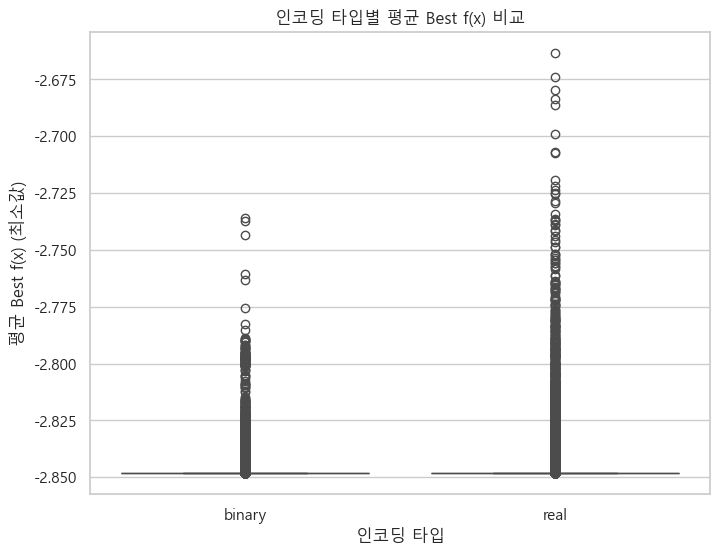

In [74]:
# 인코딩 타입별 평균 성능 비교
encoding_impact = grouped_results.groupby('encoding_type')['mean_best_fx'].mean().sort_values()
print(f"인코딩 타입별 평균 성능: {encoding_impact}")

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False

# 인코딩 타입별 평균 best_fx 비교 (범주형 vs 수치형)
plt.figure(figsize=(8, 6))
sns.boxplot(x='encoding_type', y='mean_best_fx', data=grouped_results)
plt.title('인코딩 타입별 평균 Best f(x) 비교')
plt.xlabel('인코딩 타입')
plt.ylabel('평균 Best f(x) (최소값)')
plt.show()

- 이진 인코딩이 실수 인코딩보다 평균적으로 약간 더 낮은 best_fx 값(더 좋은 성능)을 보임
- 실수 인코딩은 이진 인코딩보다 이상치(outliers)가 더 넓게 분포되어 있어 성능 편차가 더 클 수 있음

선택 연산자별 평균 성능: selection_method
selection_rank_with_elite                 -2.847910
selection_rank                            -2.847860
selection_proportional                    -2.847610
selection_tournament                      -2.847603
selection_stochastic_universal_sampling   -2.847595
Name: mean_best_fx, dtype: float64


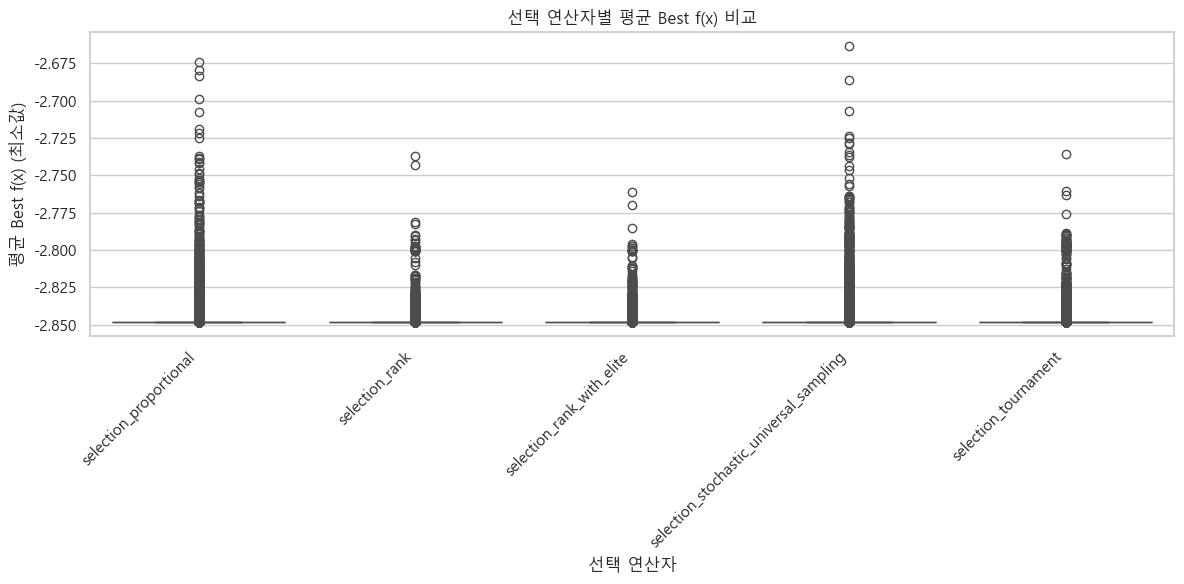

In [75]:
# 선택 연산자별 평균 성능 비교
selection_impact = grouped_results.groupby('selection_method')['mean_best_fx'].mean().sort_values()
print(f"선택 연산자별 평균 성능: {selection_impact}")

# 선택 연산자별 평균 best_fx 비교 (범주형 vs 수치형)
plt.figure(figsize=(12, 6))
# 선택 연산자 이름이 길 수 있으므로 회전 또는 y축 사용
sns.boxplot(x='selection_method', y='mean_best_fx', data=grouped_results)
plt.title('선택 연산자별 평균 Best f(x) 비교')
plt.xlabel('선택 연산자')
plt.ylabel('평균 Best f(x) (최소값)')
plt.xticks(rotation=45, ha='right') # x축 라벨 회전
plt.tight_layout() # 라벨 겹침 방지
plt.show()

교차 연산자별 평균 성능: crossover_method
crossover_blend       -2.848077
crossover_uniform     -2.847997
crossover_n_point     -2.847761
crossover_one_point   -2.847157
crossover_linear      -2.846158
Name: mean_best_fx, dtype: float64


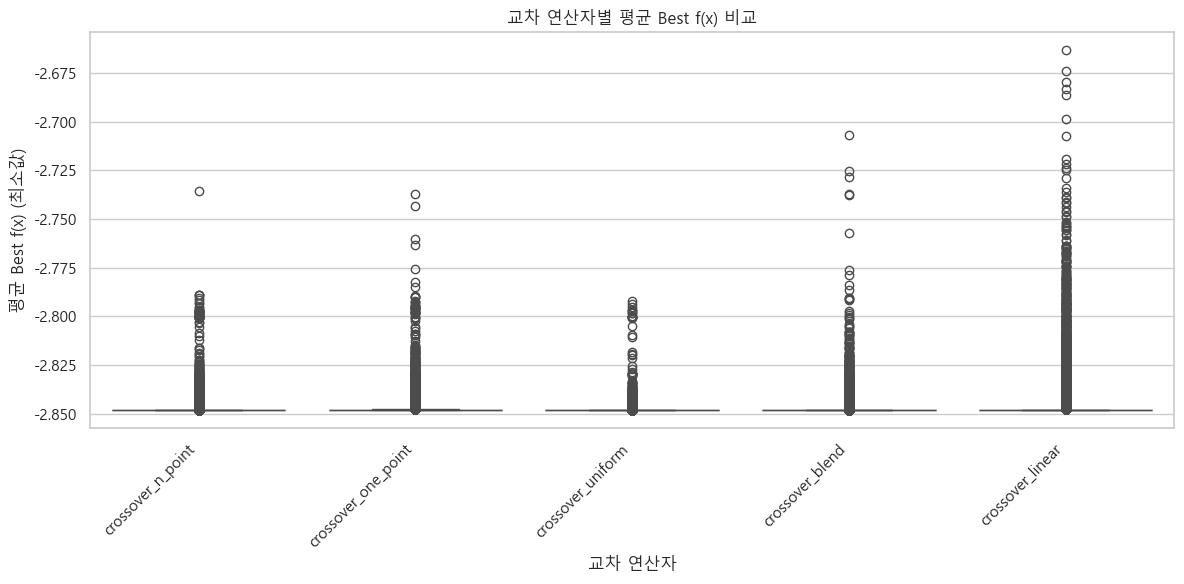

In [76]:
# 교차 연산자별 평균 성능 비교
crossover_impact = grouped_results.groupby('crossover_method')['mean_best_fx'].mean().sort_values()
print(f"교차 연산자별 평균 성능: {crossover_impact}")

# 교차 연산자별 평균 best_fx 비교
plt.figure(figsize=(12, 6))
sns.boxplot(x='crossover_method', y='mean_best_fx', data=grouped_results)
plt.title('교차 연산자별 평균 Best f(x) 비교')
plt.xlabel('교차 연산자')
plt.ylabel('평균 Best f(x) (최소값)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

돌연변이 연산자별 평균 성능: mutation_method
mutation_fitness_driven_random_deviation   -2.847874
mutation_shuffle                           -2.847871
mutation_inversion                         -2.847864
mutation_fitness_driven_bit_flip           -2.847833
mutation_shift                             -2.847803
mutation_random_deviation                  -2.847648
mutation_exchange                          -2.847550
mutation_bit_flip                          -2.847487
Name: mean_best_fx, dtype: float64


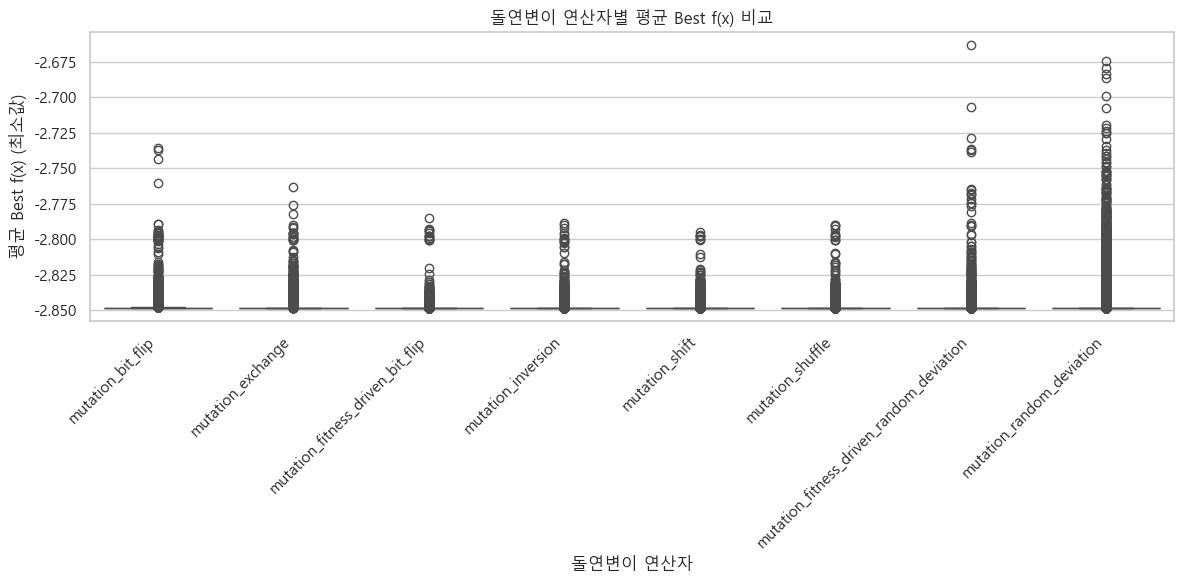

In [78]:
# 교차 연산자별 평균 성능 비교
mutation_impact = grouped_results.groupby('mutation_method')['mean_best_fx'].mean().sort_values()
print(f"돌연변이 연산자별 평균 성능: {mutation_impact}")

# 돌연변이 연산자별 평균 best_fx 비교 (범주형 vs 수치형)
plt.figure(figsize=(12, 6))
sns.boxplot(x='mutation_method', y='mean_best_fx', data=grouped_results)
plt.title('돌연변이 연산자별 평균 Best f(x) 비교')
plt.xlabel('돌연변이 연산자')
plt.ylabel('평균 Best f(x) (최소값)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

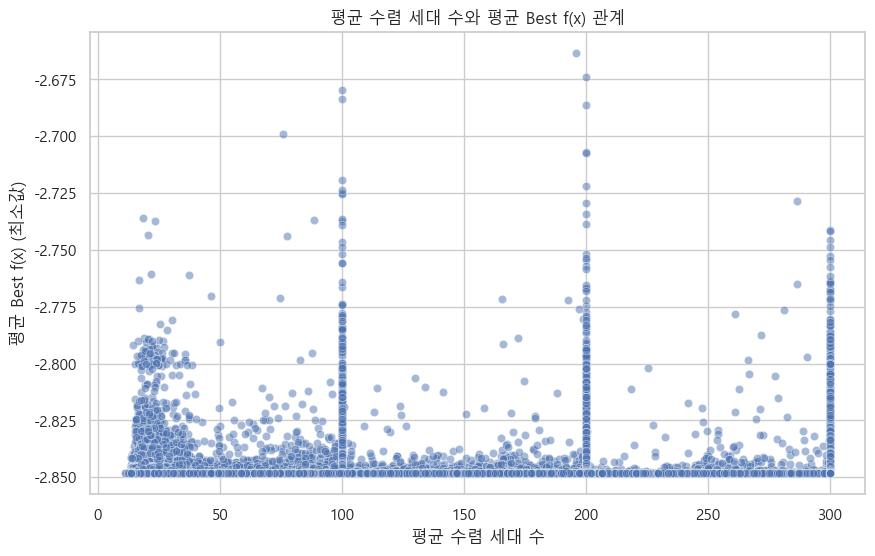

In [43]:
# 13. 수렴 속도 (generations_run) 분석 예시 (기존 플롯)
# 평균 best_fx와 평균 generations_run 간의 관계
plt.figure(figsize=(10, 6))
sns.scatterplot(x='mean_generations_run', y='mean_best_fx', data=grouped_results, alpha=0.5)
plt.title('평균 수렴 세대 수와 평균 Best f(x) 관계')
plt.xlabel('평균 수렴 세대 수')
plt.ylabel('평균 Best f(x) (최소값)')
plt.show()

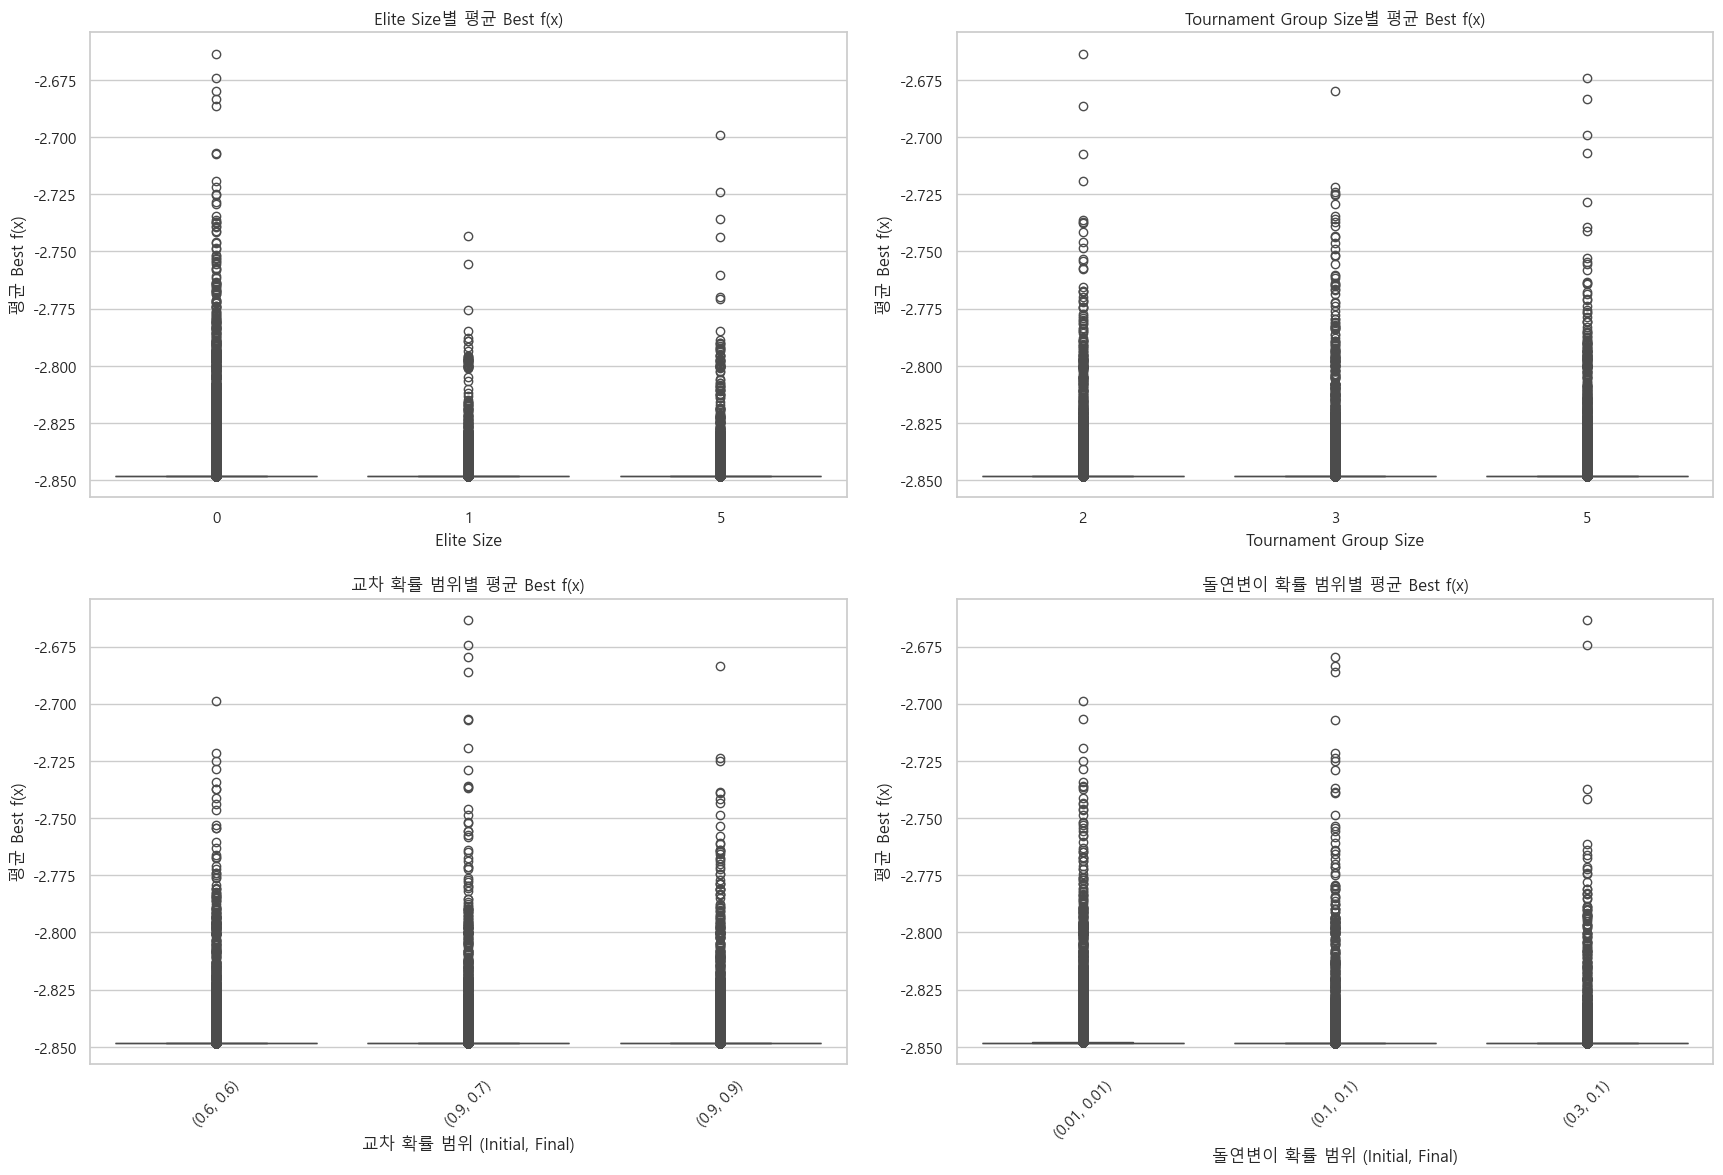

In [79]:
# 확률 범위 튜플을 문자열로 변환하는 함수 (groupby 키로 사용하기 위함)
def prob_range_to_str(initial, final):
    return f"({initial}, {final})"

grouped_results['crossover_prob_range'] = grouped_results.apply(lambda row: prob_range_to_str(row['initial_crossover_prob'], row['final_crossover_prob']), axis=1)
grouped_results['mutation_prob_range'] = grouped_results.apply(lambda row: prob_range_to_str(row['initial_mutation_prob'], row['final_mutation_prob']), axis=1)


# 이진 인코딩 데이터만 필터링하여 bits 컬럼 분석 준비
grouped_results_binary = grouped_results[grouped_results['encoding_type'] == 'binary'].copy()

# elite_size, tournament_group_size, crossover_prob_range, mutation_prob_range
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 플롯 간 간격 조정
fig.tight_layout(pad=4.0)

# Elite Size별 평균 best_fx 비교
sns.boxplot(x='elite_size', y='mean_best_fx', data=grouped_results, ax=axes[0, 0])
axes[0, 0].set_title('Elite Size별 평균 Best f(x)')
axes[0, 0].set_xlabel('Elite Size')
axes[0, 0].set_ylabel('평균 Best f(x)')

# Tournament Group Size별 평균 best_fx 비교
sns.boxplot(x='tournament_group_size', y='mean_best_fx', data=grouped_results, ax=axes[0, 1])
axes[0, 1].set_title('Tournament Group Size별 평균 Best f(x)')
axes[0, 1].set_xlabel('Tournament Group Size')
axes[0, 1].set_ylabel('평균 Best f(x)')

# Crossover Probability Range별 평균 best_fx 비교
sns.boxplot(x='crossover_prob_range', y='mean_best_fx', data=grouped_results, ax=axes[1, 0])
axes[1, 0].set_title('교차 확률 범위별 평균 Best f(x)')
axes[1, 0].set_xlabel('교차 확률 범위 (Initial, Final)')
axes[1, 0].set_ylabel('평균 Best f(x)')
# axes[1, 0].tick_params(axis='x', rotation=45, ha='right') # 'ha' 키워드 제거
axes[1, 0].tick_params(axis='x', rotation=45) # 회전만 적용


# 12. Mutation Probability Range별 평균 best_fx 비교
sns.boxplot(x='mutation_prob_range', y='mean_best_fx', data=grouped_results, ax=axes[1, 1])
axes[1, 1].set_title('돌연변이 확률 범위별 평균 Best f(x)')
axes[1, 1].set_xlabel('돌연변이 확률 범위 (Initial, Final)')
axes[1, 1].set_ylabel('평균 Best f(x)')
# axes[1, 1].tick_params(axis='x', rotation=45, ha='right') # 'ha' 키워드 제거
axes[1, 1].tick_params(axis='x', rotation=45) # 회전만 적용

plt.show()

# 2번 유전알고리즘을 통해 최적화 문제 풀이

## 코드 리뷰
- 목적함수와 제약 조건 정의
- 두 변수 $x_1, x_2$ 이진 인코딩
- 적합도 함수 정의 (해가 제약조건을 만족하는지 확인)
- 랜덤 시드 여러개 설정해서 결과 확인

In [86]:
import random
import copy

# 문제 조건
MAX_GENERATIONS = 30
POPULATION_SIZE = 10  # 부모 수 (여기서는 편의상 전체 개체 수를 부모 수로 사용)
CHROMOSOME_LENGTH = 5  # 이진수 5자리
MUTATION_RATE = 0.1
MUTATION_INDIVIDUAL_RATE = 0.2

# 제약 조건 함수
def is_feasible(x1, x2):
    if x1 < 0 or x2 < 0:
        return False
    if -x1 + x2 > 5:
        return False
    if x1 + x2 > 10:
        return False
    if -2*x1 + x2 < -10:
        return False
    return True

# 적합도 함수
def fitness_function(x1, x2):
    if is_feasible(x1, x2):
        return x1 + 2*x2
    else:
        return 0

# 이진수 -> 십진수 변환 함수
def binary_to_decimal(binary):
    return int(binary, 2)

# 개체 생성 함수
def create_individual(length):
    return [random.randint(0, 1) for _ in range(length)]

# 초기 모집단 생성 함수
def create_population(size, length):
    return [create_individual(length) for _ in range(size)]

# 선택 함수 (토너먼트 선택)
def selection(population, fitnesses, num_parents):
    parents = []
    for _ in range(num_parents):
        tournament_indices = random.sample(range(len(population)), 3)  # 토너먼트 크기 = 3
        tournament_fitnesses = [fitnesses[i] for i in tournament_indices]
        winner_index = tournament_indices[tournament_fitnesses.index(max(tournament_fitnesses))]
        parents.append(population[winner_index])
    return parents

def crossover(p1, p2):
    point = random.randint(1, len(p1) - 1)
    c1, c2 = copy.deepcopy(p1), copy.deepcopy(p2)
    c1[point:], c2[point:] = p2[point:], p1[point:]
    return c1, c2

# 돌연변이 연산 (bit-flip)
def mutation_bit_flip(ind):
    mut = copy.deepcopy(ind)
    pos = random.randint(0, len(ind)-1)
    mut[pos] = (mut[pos] + 1) % 2
    return mut

# 유전 알고리즘 메인 함수
def genetic_algorithm(random_seed):
    random.seed(random_seed)  # 시드 값 설정
    population = create_population(POPULATION_SIZE, CHROMOSOME_LENGTH * 2)  # x1, x2 모두 표현하므로 *2
    best_fitness = 0
    best_individual = None
    final_fitnesses = []  # 최종 세대 적합도 분포 저장
    final_x1 = 0
    final_x2 = 0

    for generation in range(MAX_GENERATIONS):
        # 이진수 -> 십진수 변환
        x1_binaries = [ "".join(map(str,ind[:CHROMOSOME_LENGTH])) for ind in population]
        x2_binaries = [ "".join(map(str,ind[CHROMOSOME_LENGTH:])) for ind in population]

        x1_decimals = [binary_to_decimal(binary) for binary in x1_binaries]
        x2_decimals = [binary_to_decimal(binary) for binary in x2_binaries]

        # 적합도 계산
        fitnesses = [fitness_function(x1, x2) for x1, x2 in zip(x1_decimals, x2_decimals)]
        final_fitnesses = fitnesses  # 최종 세대 적합도 분포 저장

        # 현재 세대 최고 적합도 갱신
        if max(fitnesses) > best_fitness:
            best_fitness = max(fitnesses)
            best_individual = population[fitnesses.index(max(fitnesses))]
            final_x1 = x1_decimals[fitnesses.index(max(fitnesses))]
            final_x2 = x2_decimals[fitnesses.index(max(fitnesses))]

        # 선택
        parents = selection(population, fitnesses, POPULATION_SIZE)

        # 교차
        offsprings = []
        for i in range(0, POPULATION_SIZE, 2):
            c1, c2 = crossover(parents[i % len(parents)], parents[(i + 1) % len(parents)])
            offsprings.append(c1)
            offsprings.append(c2)

        # 돌연변이
        num_mutation_individuals = int(POPULATION_SIZE * MUTATION_INDIVIDUAL_RATE)
        mutation_targets = random.sample(range(len(offsprings)), num_mutation_individuals)

        for i in mutation_targets:
            if random.random() < MUTATION_RATE:
                offsprings[i] = mutation_bit_flip(offsprings[i])

        population = offsprings

    # 최종 결과 해석
    if best_individual is not None:
        x1_final = binary_to_decimal("".join(map(str,best_individual[:CHROMOSOME_LENGTH])))
        x2_final = binary_to_decimal("".join(map(str,best_individual[CHROMOSOME_LENGTH:])))
        return x1_final, x2_final, final_fitnesses  # 최종 적합도 분포 반환
    else:
        return final_x1, final_x2, final_fitnesses  # 최종 적합도 분포 반환

# 실행 (여러 초기값에 대해 테스트)
random_seed_list = [0, 1, 2, 3, 4, 5]  # 테스트할 시드 값 리스트

for seed in random_seed_list:
    x1, x2, fitnesses = genetic_algorithm(seed)  # 결과 받음
    print(f"\n[Seed: {seed}]")
    if isinstance(x1, int): # x1이 int 타입이면 최적해를 찾은 것으로 간주
        max_fitness = fitness_function(x1, x2)
        print(f"  최적해: x1 = {x1}, x2 = {x2}, 최대값 = {max_fitness}")
        print(f"  최종 모집단 적합도 분포: {fitnesses}")
    else:
        if fitnesses:
            print(f"  최적해를 찾지 못했습니다.")
            print(f"  최종 세대 최고 적합도 개체 x1: {x1}, x2: {x2}")
            print(f"  최종 모집단 적합도 분포: {fitnesses}")
        else:
            print(f"  최적해를 찾지 못했습니다.")
            print(f"  최종 세대 적합도 정보 없음")


[Seed: 0]
  최적해: x1 = 3, x2 = 7, 최대값 = 17
  최종 모집단 적합도 분포: [17, 17, 17, 17, 17, 17, 17, 17, 17, 17]

[Seed: 1]
  최적해: x1 = 0, x2 = 0, 최대값 = 0
  최종 모집단 적합도 분포: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

[Seed: 2]
  최적해: x1 = 2, x2 = 7, 최대값 = 16
  최종 모집단 적합도 분포: [16, 16, 16, 16, 16, 16, 16, 16, 16, 16]

[Seed: 3]
  최적해: x1 = 5, x2 = 1, 최대값 = 7
  최종 모집단 적합도 분포: [7, 7, 7, 7, 7, 7, 7, 7, 7, 7]

[Seed: 4]
  최적해: x1 = 3, x2 = 3, 최대값 = 9
  최종 모집단 적합도 분포: [9, 9, 9, 9, 9, 9, 9, 9, 9, 9]

[Seed: 5]
  최적해: x1 = 3, x2 = 7, 최대값 = 17
  최종 모집단 적합도 분포: [17, 0, 17, 17, 17, 17, 17, 17, 17, 17]


# 3. 최단경로 문제 유전알고리즘으로 최적 경로 탐색
주어진 경로: ㄴ

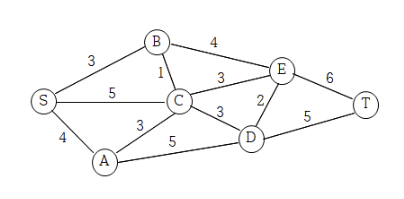

## 풀이
- S에서 출발해서 S로 돌아오느 tsp문제
- 그래프의 노드, 간선, 이동 비용 정의, 시각화를 위한 노드 좌표 정의
- GA 파라미터 설정
- 순열 리스트로 개체 표현('S' 노드는 제외-> S에서 출발해서 S로 돌아오기에 나머지 노드에 대해서만 경로 계산)
- 경로의 적합도 함수 정의(이동 비용 최소화, 존재하지 않는 간선에 패널티 부여)

Starting Genetic Algorithm...
Generation 1/100, Best Distance: 27.00, Avg Valid Distance: 27.00
Generation 11/100, Best Distance: 27.00, Avg Valid Distance: 27.47
Generation 21/100, Best Distance: 27.00, Avg Valid Distance: 27.55
Generation 31/100, Best Distance: 27.00, Avg Valid Distance: 27.23
Generation 41/100, Best Distance: 27.00, Avg Valid Distance: 27.73
Generation 51/100, Best Distance: 27.00, Avg Valid Distance: 27.56
Generation 61/100, Best Distance: 27.00, Avg Valid Distance: 27.24
Generation 71/100, Best Distance: 27.00, Avg Valid Distance: 27.56
Generation 81/100, Best Distance: 27.00, Avg Valid Distance: 27.43
Generation 91/100, Best Distance: 27.00, Avg Valid Distance: 27.25

--- Optimization Complete ---
Best Path Found: ['S', 'A', 'D', 'T', 'E', 'C', 'B', 'S']
Best Distance: 27


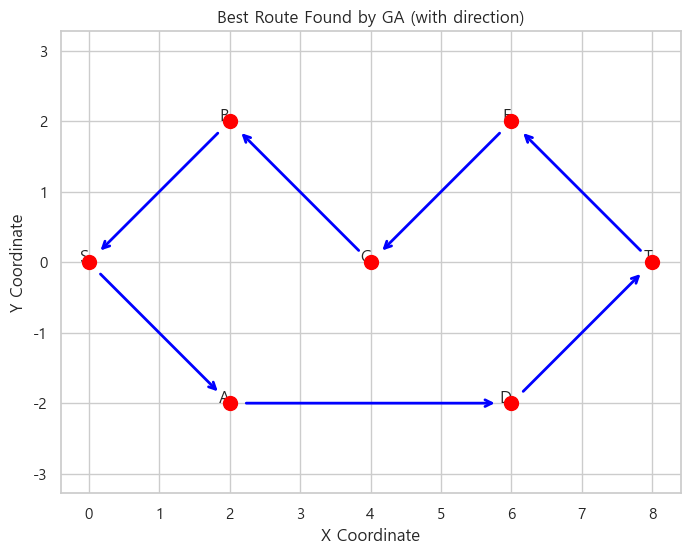

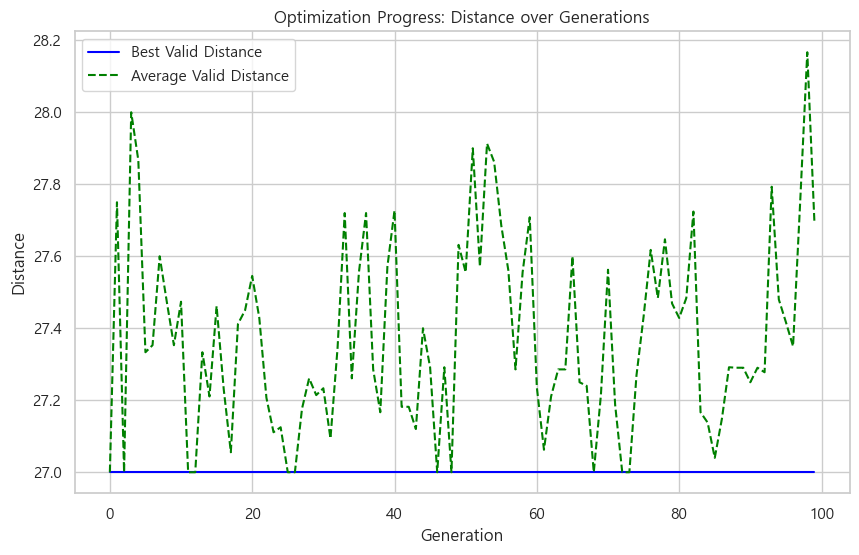

In [88]:
import random
import copy
import matplotlib.pyplot as plt

random.seed(0)

# 1. 노드 및 간선 정보 정의
nodes = {'S', 'A', 'B', 'C', 'D', 'E', 'T'}
edges = {
    ('S', 'A'): 4, ('A', 'S'): 4,
    ('S', 'B'): 3, ('B', 'S'): 3,
    ('S', 'C'): 5, ('C', 'S'): 5,
    ('A', 'C'): 3, ('C', 'A'): 3,
    ('A', 'D'): 5, ('D', 'A'): 5,
    ('B', 'C'): 1, ('C', 'B'): 1,
    ('B', 'E'): 4, ('E', 'B'): 4,
    ('C', 'D'): 3, ('D', 'C'): 3,
    ('C', 'E'): 3, ('E', 'C'): 3,
    ('D', 'E'): 2, ('E', 'D'): 2,
    ('D', 'T'): 5, ('T', 'D'): 5,
    ('E', 'T'): 6, ('T', 'E'): 6
}

# 노드 좌표를 딕셔너리로 정의 (시각화를 위해)
node_coords = {
    'S': (0, 0),
    'A': (2, -2),
    'B': (2, 2),
    'C': (4, 0),
    'D': (6, -2),
    'E': (6, 2),
    'T': (8, 0)
}

# 2. 유전 알고리즘 파라미터 설정
POPULATION_SIZE = 100
MAX_GENERATIONS = 100
CROSSOVER_PROBABILITY = 0.9
MUTATION_PROBABILITY = 0.1
ELITE_SIZE = 10
INVALID_PATH_PENALTY = 100


# 3. Individual 클래스 및 관련 함수 정의
class Individual:
    def __init__(self, path):
        self.path = path
        self.fitness = self.calculate_fitness()

    def calculate_fitness(self):
        total_distance = 0
        full_path = ['S'] + self.path + ['S']

        # 매우 큰 페널티 값. 어떤 유효한 경로의 총 거리보다 커야 함.
        # INVALID_PATH_PENALTY = 100

        for i in range(len(full_path) - 1):
            u, v = full_path[i], full_path[i+1]
            # 해당 간선 (u, v)가 edges 딕셔너리에 존재하는지 확인
            if (u, v) not in edges:
                # 존재하지 않으면 이 경로는 유효하지 않으므로 큰 페널티를 부여
                # 최소화 문제(거리) -> 최대화 문제(적합도) 변환이므로,
                # 거리가 매우 커지도록 (음수 적합도가 매우 작아지도록) 설정
                return -INVALID_PATH_PENALTY

            total_distance += edges[(u, v)]

        # 유효한 경로인 경우 정상적으로 적합도 계산
        return -total_distance # 최소화 문제이므로 음수 반환

def create_initial_population(node_set, population_size):
    population = []
    other_nodes = list(node_set - {'S'})  # 'S'를 제외한 나머지 노드
    for _ in range(population_size):
        path = random.sample(other_nodes, len(other_nodes)) # 'S'를 제외한 노드의 순열
        population.append(Individual(list(path)))
    return population

# 4. 유전 연산 함수 정의
def selection(population, elite_size):
    # 적합도(fitness, 음수 거리) 내림차순 정렬 -> 거리는 오름차순
    sorted_population = sorted(population, key=lambda ind: ind.fitness, reverse=True)
    # 엘리트 선택 + 나머지 랜덤 선택 (정렬된 리스트에서)
    return sorted_population[:elite_size] + random.choices(sorted_population, k=len(population) - elite_size)

def crossover(parent1, parent2):
    # Ordered Crossover (OX1) 변형
    p1_path = parent1.path
    p2_path = parent2.path
    length = len(p1_path)
    # 교차 지점 두 개 랜덤 선택
    start, end = sorted(random.sample(range(length), 2))

    # 자식 경로 생성 및 부모1의 중간 부분 복사
    child_path = [None] * length
    child_path[start:end+1] = p1_path[start:end+1]

    # 부모2의 노드들을 순서대로 순회하며 자식 경로의 빈 칸 채우기
    remaining_nodes_in_p2_order = [node for node in p2_path if node not in p1_path[start:end+1]]
    
    current_remaining_index = 0
    for i in range(length):
        if child_path[i] is None:
            child_path[i] = remaining_nodes_in_p2_order[current_remaining_index]
            current_remaining_index += 1
            
    return Individual(child_path) # 새로운 Individual 객체 반환

def mutate(individual):
    # Swap mutation (두 노드의 위치를 바꿈)
    mutated_path = individual.path[:] # 경로 복사
    if len(mutated_path) > 1: # 노드가 2개 이상일 때만 돌연변이 가능
        idx1, idx2 = random.sample(range(len(mutated_path)), 2)
        mutated_path[idx1], mutated_path[idx2] = mutated_path[idx2], mutated_path[idx1]
    return Individual(mutated_path) # 새로운 Individual 객체 반환


# 5. 경로 유효성 검사 및 거리 계산 함수 정의 (GA 로직에서는 사용되지 않음, 디버깅/확인용)
# calculate_total_distance 함수는 Individual 클래스의 calculate_fitness와 동일한 역할을 하므로 중복입니다.
# is_valid_path 함수는 모든 노드를 방문하고 모든 간선이 존재하는지 확인하지만, 
# 현재 GA는 permutation 기반이라 모든 노드 방문은 보장되나, 간선 존재 여부는 calculate_fitness에서 체크합니다.

# 6. 결과 시각화 함수 정의
def visualize_route(best_path):
    full_path = ['S'] + best_path + ['S']
    # 노드 좌표는 그대로 사용

    plt.figure(figsize=(8, 6))
    
    # 노드 위치에 점과 이름 표시
    for node, (nx, ny) in node_coords.items():
        plt.plot(nx, ny, 'o', markersize=10, color='red', zorder=5) # 노드 점 표시 (화살표보다 위에 오도록 zorder 설정)
        plt.text(nx, ny, node, fontsize=12, ha='right') # 노드 이름 표시

    # 최적 경로의 각 간선에 화살표 그리기
    for i in range(len(full_path) - 1):
        start_node = full_path[i]
        end_node = full_path[i+1]
        (x1, y1) = node_coords[start_node]
        (x2, y2) = node_coords[end_node]

        # annotate 함수를 사용하여 화살표 그리기
        plt.annotate(
            '', xy=(x2, y2), xycoords='data',
            xytext=(x1, y1), textcoords='data',
            arrowprops=dict(
                arrowstyle='->',    # 화살표 스타일 지정
                color='blue',       # 화살표 색상
                lw=2,               # 선 굵기
                shrinkA=12,         # 시작점에서 화살표를 약간 줄여 노드와 겹치지 않게 함
                shrinkB=12,         # 끝점에서 화살표를 약간 줄여 노드와 겹치지 않게 함
                connectionstyle='arc3,rad=0' # 직선 화살표
            )
        )

        # (선택 사항) 간선 위에 거리 표시 - 그래프가 복잡해질 수 있습니다.
        # mid_x = (x1 + x2) / 2
        # mid_y = (y1 + y2) / 2
        # distance = edges.get((start_node, end_node), '?') # 간선 거리를 가져옴
        # plt.text(mid_x, mid_y, str(distance), fontsize=8, color='gray', ha='center', va='bottom')


    plt.title('Best Route Found by GA (with direction)')
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.grid(True)
    plt.axis('equal') # x, y 축 스케일을 같게 하여 실제 그래프 모양에 가깝게 표시
    # plt.legend() # 각 경로 세그먼트가 독립적이므로 범례는 불필요
    plt.show()

# 7. 메인 함수
def main():
    population = create_initial_population(nodes, POPULATION_SIZE)
    best_individual = None # 전체 세대 중 가장 좋은 개체
    best_fitness_history = [] # 각 세대별 최고 적합도 (거리) 기록
    avg_fitness_history = []  # 각 세대별 평균 적합도 (거리) 기록

    print("Starting Genetic Algorithm...")

    for generation in range(MAX_GENERATIONS):
        # 적합도 평가는 Individual 객체 생성 시 수행됨.
        # 여기서는 단순히 현재 population의 적합도를 사용.

        # 최고 개체 갱신 (현재 세대에서 가장 좋은 개체 찾기)
        best_of_generation = max(population, key=lambda ind: ind.fitness)

        # 전체 세대를 통틀어 가장 좋은 개체 업데이트
        # 페널티 값(-1000000)을 가진 개체는 best_individual이 되지 않도록 처리
        if best_of_generation.fitness > -INVALID_PATH_PENALTY: # 유효한 경로만 고려
             if best_individual is None or best_of_generation.fitness > best_individual.fitness:
                best_individual = copy.deepcopy(best_of_generation)

        # 통계 기록 (유효한 경로의 적합도만 평균에 포함시키는 것도 고려 가능)
        # 여기서는 모든 개체의 적합도를 평균냄 (페널티 값 포함)
        valid_fitnesses = [ind.fitness for ind in population if ind.fitness > -INVALID_PATH_PENALTY]
        if valid_fitnesses: # 유효한 경로가 하나라도 있는 경우
             avg_fitness = sum(valid_fitnesses) / len(valid_fitnesses)
        else: # 모든 경로가 유효하지 않은 경우
             avg_fitness = -INVALID_PATH_PENALTY # 또는 0이나 다른 의미있는 값

        # 기록 시에는 거리로 변환 (- 적합도)
        best_fitness_history.append(-best_individual.fitness if best_individual and best_individual.fitness > -INVALID_PATH_PENALTY else abs(INVALID_PATH_PENALTY)) # 유효하지 않으면 페널티 값 표시
        avg_fitness_history.append(-avg_fitness)

        if generation % 10 == 0:
            print(f"Generation {generation + 1}/{MAX_GENERATIONS}, Best Distance: {best_fitness_history[-1]:.2f}, Avg Valid Distance: {avg_fitness_history[-1]:.2f}")

        # ----- 다음 세대 생성 -----

        # 선택: 다음 세대 생성을 위한 부모 선택
        parents = selection(population, ELITE_SIZE)

        # 교차: 선택된 부모로부터 자손 생성
        offsprings = []
        # parents 리스트의 길이가 홀수일 경우 마지막 한 명은 교차에 참여 못함 (현재 POPULATION_SIZE=100으로 짝수라 문제 없음)
        for i in range(0, len(parents) - 1, 2): 
            parent1 = parents[i]
            parent2 = parents[i+1]
            if random.random() < CROSSOVER_PROBABILITY:
                # 두 자식 생성
                offsprings.append(crossover(parent1, parent2))
                offsprings.append(crossover(parent2, parent1)) # 부모 순서 바꿔서 한 번 더
            else:
                # 교차하지 않으면 부모 그대로 자손으로
                offsprings.append(parent1)
                offsprings.append(parent2)

        # 돌연변이: 생성된 자손들에게 돌연변이 적용
        mutated_offsprings = []
        for offspring in offsprings:
            if random.random() < MUTATION_PROBABILITY:
                mutated_offsprings.append(mutate(offspring))
            else:
                mutated_offsprings.append(offspring)
                
        # 자손의 수가 POPULATION_SIZE와 다를 경우 보정 (엘리트 개체 수 고려 등)
        # 간단하게는 자손들로 다음 세대를 구성 (세대 교체 방식)
        # 엘리트 개체를 다음 세대에 보존하는 방식도 흔함
        # 현재 코드는 자손만으로 다음 세대 구성 (엘리트 보존은 selection 단계에서 간접적으로 이루어짐)
        # population = mutated_offsprings[:POPULATION_SIZE] # 개체 수가 넘칠 경우 자름

        # 여기서는 selection에서 POPULATION_SIZE와 동일한 수의 부모를 뽑고
        # 교차/돌연변이로 동일한 수의 자손을 만드는 방식으로 구현된 것으로 보임.
        # 따라서 그대로 다음 세대로 넘겨도 됩니다.
        population = mutated_offsprings


    print("\n--- Optimization Complete ---")
    if best_individual and best_individual.fitness > -INVALID_PATH_PENALTY:
        print("Best Path Found:", ['S'] + best_individual.path + ['S'])
        print("Best Distance:", -best_individual.fitness)
        # 최적 경로 시각화
        visualize_route(best_individual.path)
    else:
        print("Could not find a valid path within the given generations.")
        print("Best fitness found (may be invalid):", best_individual.fitness if best_individual else "None")


    # 적합도 변화 그래프 (거리 기준)
    plt.figure(figsize=(10, 6))
    plt.plot(best_fitness_history, label='Best Valid Distance', color='blue')
    plt.plot(avg_fitness_history, label='Average Valid Distance', color='green', linestyle='--')
    plt.xlabel('Generation')
    plt.ylabel('Distance')
    plt.title('Optimization Progress: Distance over Generations')
    plt.legend()
    plt.grid(True)
    plt.show()


if __name__ == "__main__":
    main()

## 3번 결과 분석
- 파란색 선: 각 세대에서 찾은 가장 좋은 유효 경로의 거리(최소 거리) 변
- 녹색 점선: 각 세대에서 유효한 경로를 가진 개체들의 평균 거리 변화
- 개체군 전체의 평균적인 품질은 계속 변화하지만, 가장 좋은 개체는 변동 없이 유지되고 있음

# 4. 수업시간표 작성
## 풀이
- 수업 목록, 강의실, 요일/시간 정보, 학년별 고정된 필수 수업, 학년별 수강 금지 시간대 등 시간표 구성에 필요한 다양한 제약 조건과 데이터 정의
- 각 수업이 배치될 수 있는 시간 슬록 옵션들을 미리 계산(각 학년의 고정 수업을 교려해 처음부터 불가능한 시간대 배제 후 탐색하게끔 해서 계산량 최소화)
- 개체는 전체 수업의 개수 리스트로 표현(각 수업에 대해 미리 계산된 가능한 시간 슬롯 옵션들 중 하나를 선택)

- 위반 유형 체크(하드, 소프트 위반)
- 하드 위반
    - 같은 학년의 학생이 동시에 두 개 이상의 수업을 들어야 하는 경우
    - 한 교수가 동시에 두 개 이상의 수업을 해야 하는 경우
    - 수업이 점심 시간대에 배정된 경우
    - 수업이 고정 수업 시간대에 배정된 경우
- 소프트 위반
    - 한 교수가 일주일에 4일 미만으로 강의하는 경우(이근호 교수님, 권수태 교수님의 경우는 문제 정의상 불가피)
- 위반 개수를 기반으로 적합도 계산 후 최소화하는 개체 탐

=== 최종 결과 ===
Best Fitness: -2
Violation breakdown:
  year_conflict: 0
  prof_conflict: 0
  lunch: 0
  forbidden: 0
  soft_days: 2


C:\Users\brigh\AppData\Local\Temp\ipykernel_26108\1490221295.py:170: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(profs))


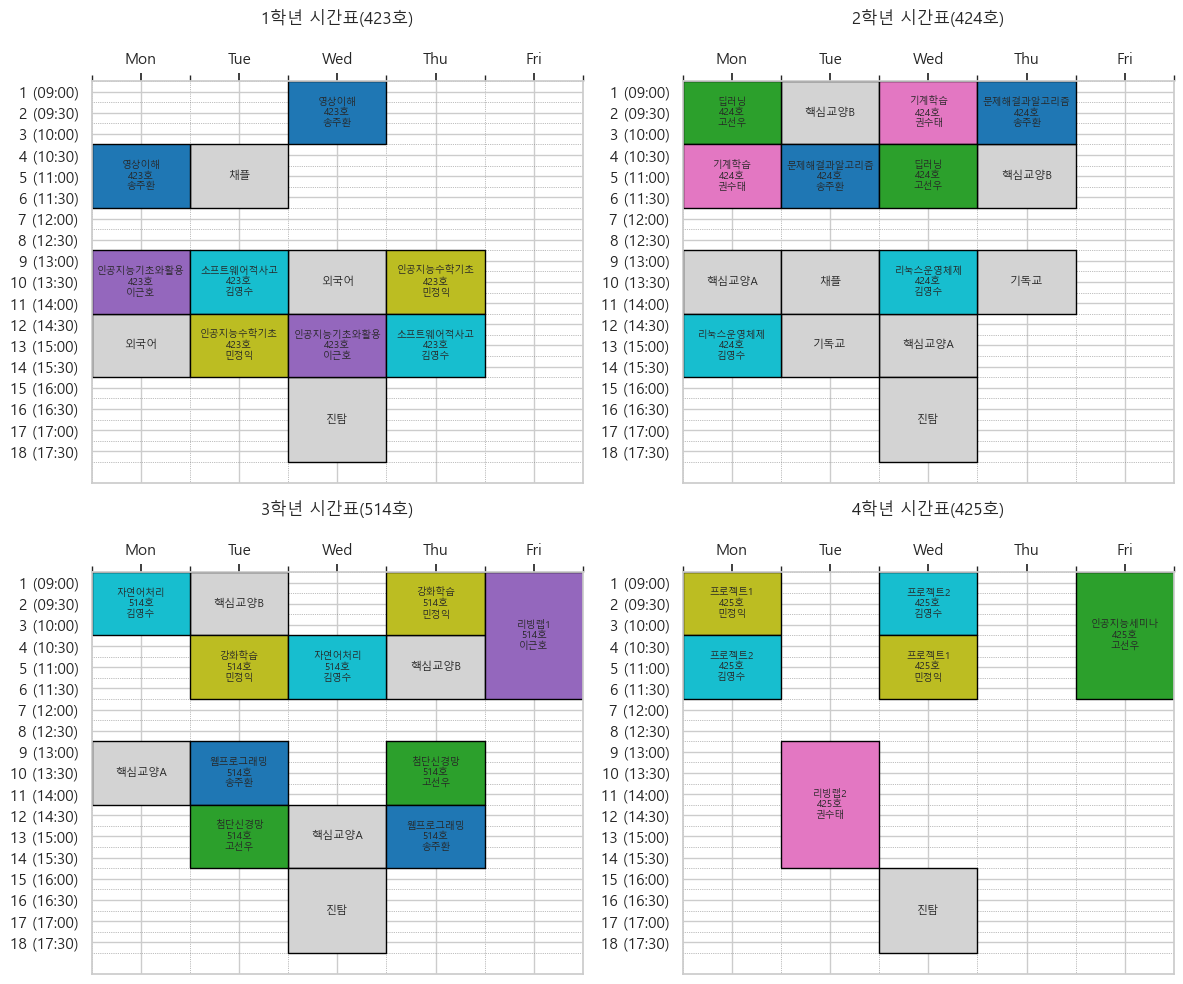

In [90]:
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 시드 고정
np.random.seed(0)
random.seed(0)

# --- 문제 데이터 ---
days = ["Mon", "Tue", "Wed", "Thu", "Fri"]
rooms = {1: "423호", 2: "424호", 3: "514호", 4: "425호"}
courses = [
    (1, "영상이해", "송주환", "1.5"),
    (1, "인공지능기초와활용", "이근호", "1.5"),
    (1, "인공지능수학기초", "민정익", "1.5"),
    (1, "소프트웨어적사고", "김영수", "1.5"),
    (3, "리빙랩1", "이근호", "3h"),
    (2, "문제해결과알고리즘", "송주환", "1.5"),
    (2, "리눅스운영체제", "김영수", "1.5"),
    (2, "기계학습", "권수태", "1.5"),
    (2, "딥러닝", "고선우", "1.5"),
    (3, "웹프로그래밍", "송주환", "1.5"),
    (3, "자연어처리", "김영수", "1.5"),
    (3, "강화학습", "민정익", "1.5"),
    (3, "첨단신경망", "고선우", "1.5"),
    (4, "인공지능세미나", "고선우", "3h"),
    (4, "리빙랩2", "권수태", "3h"),
    (4, "프로젝트1", "민정익", "1.5"),
    (4, "프로젝트2", "김영수", "1.5"),
]

# 학년별 고정 수업 (진탐 포함)
fixed_slots = {
    1: [(0, 11, 3, "외국어"), (2, 8, 3, "외국어"), (1, 3, 3, "채플"), (2, 14, 4, "진탐")],
    2: [(0, 8, 3, "핵심교양A"), (2, 11, 3, "핵심교양A"),
        (1, 0, 3, "핵심교양B"), (3, 3, 3, "핵심교양B"),
        (1, 8, 3, "채플"), (1, 11, 3, "기독교"), (3, 8, 3, "기독교"),
        (2, 14, 4, "진탐")],
    3: [(0, 8, 3, "핵심교양A"), (2, 11, 3, "핵심교양A"),
        (1, 0, 3, "핵심교양B"), (3, 3, 3, "핵심교양B"),
        (2, 14, 4, "진탐")],
    4: [(2, 14, 4, "진탐")]
}

# forbidden 시간대
forbidden = {
    1: {(0, p) for p in [12,13,14]} | {(2, p) for p in [9,10,11,15,16,17,18]} | {(1, p) for p in [4,5,6]},
    2: {(0, p) for p in [9,10,11]} | {(2, p) for p in [12,13,14,15,16,17,18]} |
       {(1, p) for p in [1,2,3]} | {(3, p) for p in [4,5,6]} |
       {(1, p) for p in [9,10,11,12,13,14]} | {(3, p) for p in [9,10,11]},
    3: {(0, p) for p in [9,10,11]} | {(2, p) for p in [12,13,14,15,16,17,18]} |
       {(1, p) for p in [1,2,3]} | {(3, p) for p in [4,5,6]},
    4: {(2, p) for p in [15,16,17,18]}
}

# 1.5h 짝꿍 슬롯 정의
slot_pairs_1_5 = [
    ((0,1),(2,4)), ((0,4),(2,1)), ((0,9),(2,12)), ((0,12),(2,9)),
    ((1,1),(3,4)), ((1,4),(3,1)), ((1,9),(3,12)), ((1,12),(3,9))
]

# 가능한 슬롯 생성 (3h: 월~목 우선, 그 다음 금 오전/오후)
possible_slots = []
for year, _, _, typ in courses:
    if typ == "1.5":
        choices = slot_pairs_1_5
    else:
        choices = []
        for d in range(4):
            for start in range(1, 10):
                if any((d, start+off) in forbidden[year] for off in range(6)):
                    continue
                choices.append(((d, start),))
        for start in (1, 9):
            if all((4, start+off) not in forbidden[year] for off in range(6)):
                choices.append(((4, start),))
    length = 3 if typ=="1.5" else 6
    filtered = [
        ch for ch in choices
        if all((d, p+off) not in forbidden[year] for d,p in ch for off in range(length))
    ]
    possible_slots.append(filtered)

# 크로모솜 디코드
def decode_gene(gene):
    assignments = []
    for idx, g in enumerate(gene):
        year, name, prof, typ = courses[idx]
        ch = possible_slots[idx][g]
        if typ == "1.5":
            for d, p in ch:
                for off in range(3):
                    assignments.append((year, name, prof, d, p+off))
        else:
            d, p = ch[0]
            for off in range(6):
                assignments.append((year, name, prof, d, p+off))
    return assignments

# 적합도 및 위반 내역 계산
def fitness_and_violations(gene):
    assign = decode_gene(gene)
    vio = {'year_conflict':0,'prof_conflict':0,'lunch':0,'forbidden':0,'soft_days':0}
    occ_y, occ_p, prof_days = {}, {}, {}
    for year,name,prof,d,p in assign:
        if occ_y.get((year,d,p)): vio['year_conflict']+=1
        occ_y.setdefault((year,d,p),[]).append(name)
        if (prof,d,p) in occ_p: vio['prof_conflict']+=1
        occ_p[(prof,d,p)] = name
        if p in (7,8): vio['lunch']+=1
        if (d,p) in forbidden[year]: vio['forbidden']+=1
        prof_days.setdefault(prof,set()).add(d)
    for ds in prof_days.values():
        if len(ds)<4: vio['soft_days'] += (4-len(ds))
    hard = vio['year_conflict']+vio['prof_conflict']+vio['lunch']+vio['forbidden']
    soft = vio['soft_days']
    return -(100*hard + soft), vio

# GA 파라미터 및 실행
NUM = len(courses)
POP, GENS, TOURN, CROSS, MUT, ELITE = 100, 200, 3, 0.8, 0.2, 2
population = [(*fitness_and_violations([random.randrange(len(ps)) for ps in possible_slots]), [random.randrange(len(ps)) for ps in possible_slots]) for _ in range(POP)]
best = max(population, key=lambda x: x[0])
for _ in range(GENS):
    new_pop = sorted(population, key=lambda x: x[0], reverse=True)[:ELITE]
    while len(new_pop) < POP:
        # 토너먼트 선택(tourn = 3)
        p1 = max(random.sample(population, TOURN), key=lambda x: x[0])[2]
        p2 = max(random.sample(population, TOURN), key=lambda x: x[0])[2]
        # 1점 교
        if random.random() < CROSS:
            pt = random.randint(1, NUM-1)
            c1, c2 = p1[:pt] + p2[pt:], p2[:pt] + p1[pt:]
        else:
            c1, c2 = p1[:], p2[:]
        for child in (c1, c2):
            for i in range(NUM):
                # 무작위 재설정
                if random.random() < MUT:
                    child[i] = random.randrange(len(possible_slots[i]))
            new_pop.append((*fitness_and_violations(child), child))
            if len(new_pop) >= POP:
                break
    population = new_pop
    curr = max(population, key=lambda x: x[0])
    if curr[0] > best[0]:
        best = curr

bf, bv, bg = best
print("=== 최종 결과 ===")
print("Best Fitness:", bf)
print("Violation breakdown:")
for k, v in bv.items():
    print(f"  {k}: {v}")

# 시간표 구축 (18교시)
schedule = {y: [["" for _ in days] for _ in range(18)] for y in range(1,5)}
schedule_prof = {y: [["" for _ in days] for _ in range(18)] for y in range(1,5)}
for year,name,prof,d,p in decode_gene(bg):
    schedule[year][p-1][d] = name
    schedule_prof[year][p-1][d] = prof

# 교수색 & y축 라벨 정의
profs = list({prof for *_ ,prof,_ in courses})
cmap = plt.cm.get_cmap('tab10', len(profs))
colors = {prof: cmap(i) for i, prof in enumerate(profs)}
yticks = list(range(18))
ylabels = [f"{i+1} ({9 + (i//2):02d}:{(i%2)*30:02d})" for i in yticks]

# 시각화 (2x2)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for idx, ax in enumerate(axes, start=1):
    ax.set_title(f"{idx}학년 시간표({rooms[idx]})", pad=20)
    ax.xaxis.tick_top()
    ax.set_xticks(range(5)); ax.set_xticklabels(days)
    ax.set_yticks(yticks); ax.set_yticklabels(ylabels)
    ax.set_ylim(17.5, -0.5); ax.set_xlim(-0.5, 4.5)
    ax.set_xticks(np.arange(-0.5, 5, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 19, 1), minor=True)
    ax.grid(which="minor", color="gray", linestyle=":", linewidth=0.5)

    # 고정 수업 (회색)
    for day, st, span, nm in fixed_slots[idx]:
        rect = Rectangle((day-0.5, st-0.5), 1, span, facecolor='lightgrey', edgecolor='black')
        ax.add_patch(rect)
        ax.text(day, st + (span-1)/2, nm, ha="center", va="center", fontsize=8)

    # 가변 수업 (병합, 색상, 강의실 포함)
    for day in range(5):
        per = 0
        while per < 18:
            nm = schedule[idx][per][day]
            pf = schedule_prof[idx][per][day]
            if nm:
                run = 1
                while per+run < 18 and schedule[idx][per+run][day] == nm:
                    run += 1
                room = rooms[idx]
                color = colors[pf]
                rect = Rectangle((day-0.5, per-0.5), 1, run, facecolor=color, edgecolor='black')
                ax.add_patch(rect)
                ax.text(day, per + (run-1)/2, f"{nm}\n{room}\n{pf}", ha="center", va="center", fontsize=7)
                per += run
            else:
                per += 1

plt.tight_layout()
plt.show()
